# Census Income Classification & Customer Segmentation
**JPMorgan Chase & Co. — Data Science Take-Home Project** | Zhilin Chen · March 2026

---

## Part I: Data Exploration

**Goal:** Understand the raw dataset, identify data quality issues, and discover patterns that will inform preprocessing and modeling decisions.

**Dataset:** U.S. Census Bureau Current Population Survey, 1994–1995
- 199,523 records × 40 demographic/employment variables
- Binary income label: above or below \$50k annually
- Includes a census sampling weight (important — used in model training)

### 1.1 Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from pathlib import Path
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

### 1.2 Load Data

Load the raw census data and parse column names from the `.columns` file.

In [ ]:
drive.mount('/content/drive')
DATA_PATH = Path('/content/census-bureau.data')
COLS_PATH = Path('/content/census-bureau.columns')
def read_columns(cols_path):
    raw = cols_path.read_text(encoding="utf-8", errors="ignore").strip().splitlines()
    return [c.strip().replace(" ", "_").replace("-", "_").replace("/", "_") for c in raw if c.strip()]
cols = read_columns(COLS_PATH)
df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=cols,
    na_values=["?", " ?", " NA", "NA", ""],
    skipinitialspace=True
)
df[cols[-1]] = df[cols[-1]].str.strip()
print(df.shape)
print(df.dtypes)
print(df[cols[-1]].value_counts())

Mounted at /content/drive
(199523, 42)
age                                             int64
class_of_worker                                object
detailed_industry_recode                        int64
detailed_occupation_recode                      int64
education                                      object
wage_per_hour                                   int64
enroll_in_edu_inst_last_wk                     object
marital_stat                                   object
major_industry_code                            object
major_occupation_code                          object
race                                           object
hispanic_origin                                object
sex                                            object
member_of_a_labor_union                        object
reason_for_unemployment                        object
full_or_part_time_employment_stat              object
capital_gains                                   int64
capital_losses                             

### 1.3 Label Distribution

**Finding 1:** The target variable is severely imbalanced. Only ~6% of records earn above \$50k.
This means **accuracy is a misleading metric** — a model predicting 'low income' for everyone achieves >93% accuracy while being useless for marketing.
→ We will use **AUC-ROC** as the primary evaluation metric.

In [ ]:
label_counts = df[cols[-1]].value_counts()
label_pct    = df[cols[-1]].value_counts(normalize=True) * 100

print("Label distribution (raw data):")
for label, count in label_counts.items():
    print(f"  {label:<15} {count:>8,}  ({label_pct[label]:.2f}%)")
print(f"  {'Total':<15} {len(df):>8,}")

Label distribution (raw data):
  - 50000.         187,141  (93.79%)
  50000+.           12,382  (6.21%)
  Total            199,523


### 1.4 Missing Value Analysis

**Finding 2:** Four migration columns have ~50% missing values — too high for any imputation to recover signal. Several other columns are predominantly 'Not in universe'.
→ These will be **dropped entirely** in preprocessing.

In [ ]:
# missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(missing_df)

                                missing_count  missing_pct
migration_code_change_in_msa            99696        49.97
migration_code_move_within_reg          99696        49.97
migration_code_change_in_reg            99696        49.97
migration_prev_res_in_sunbelt           99696        49.97
country_of_birth_father                  6713         3.36
country_of_birth_mother                  6119         3.07
country_of_birth_self                    3393         1.70
hispanic_origin                           874         0.44
state_of_previous_residence               708         0.35


### 1.5 Feature Distributions

Visualize distributions of all numeric and categorical features to understand their range, skewness, and relationship with the income label.

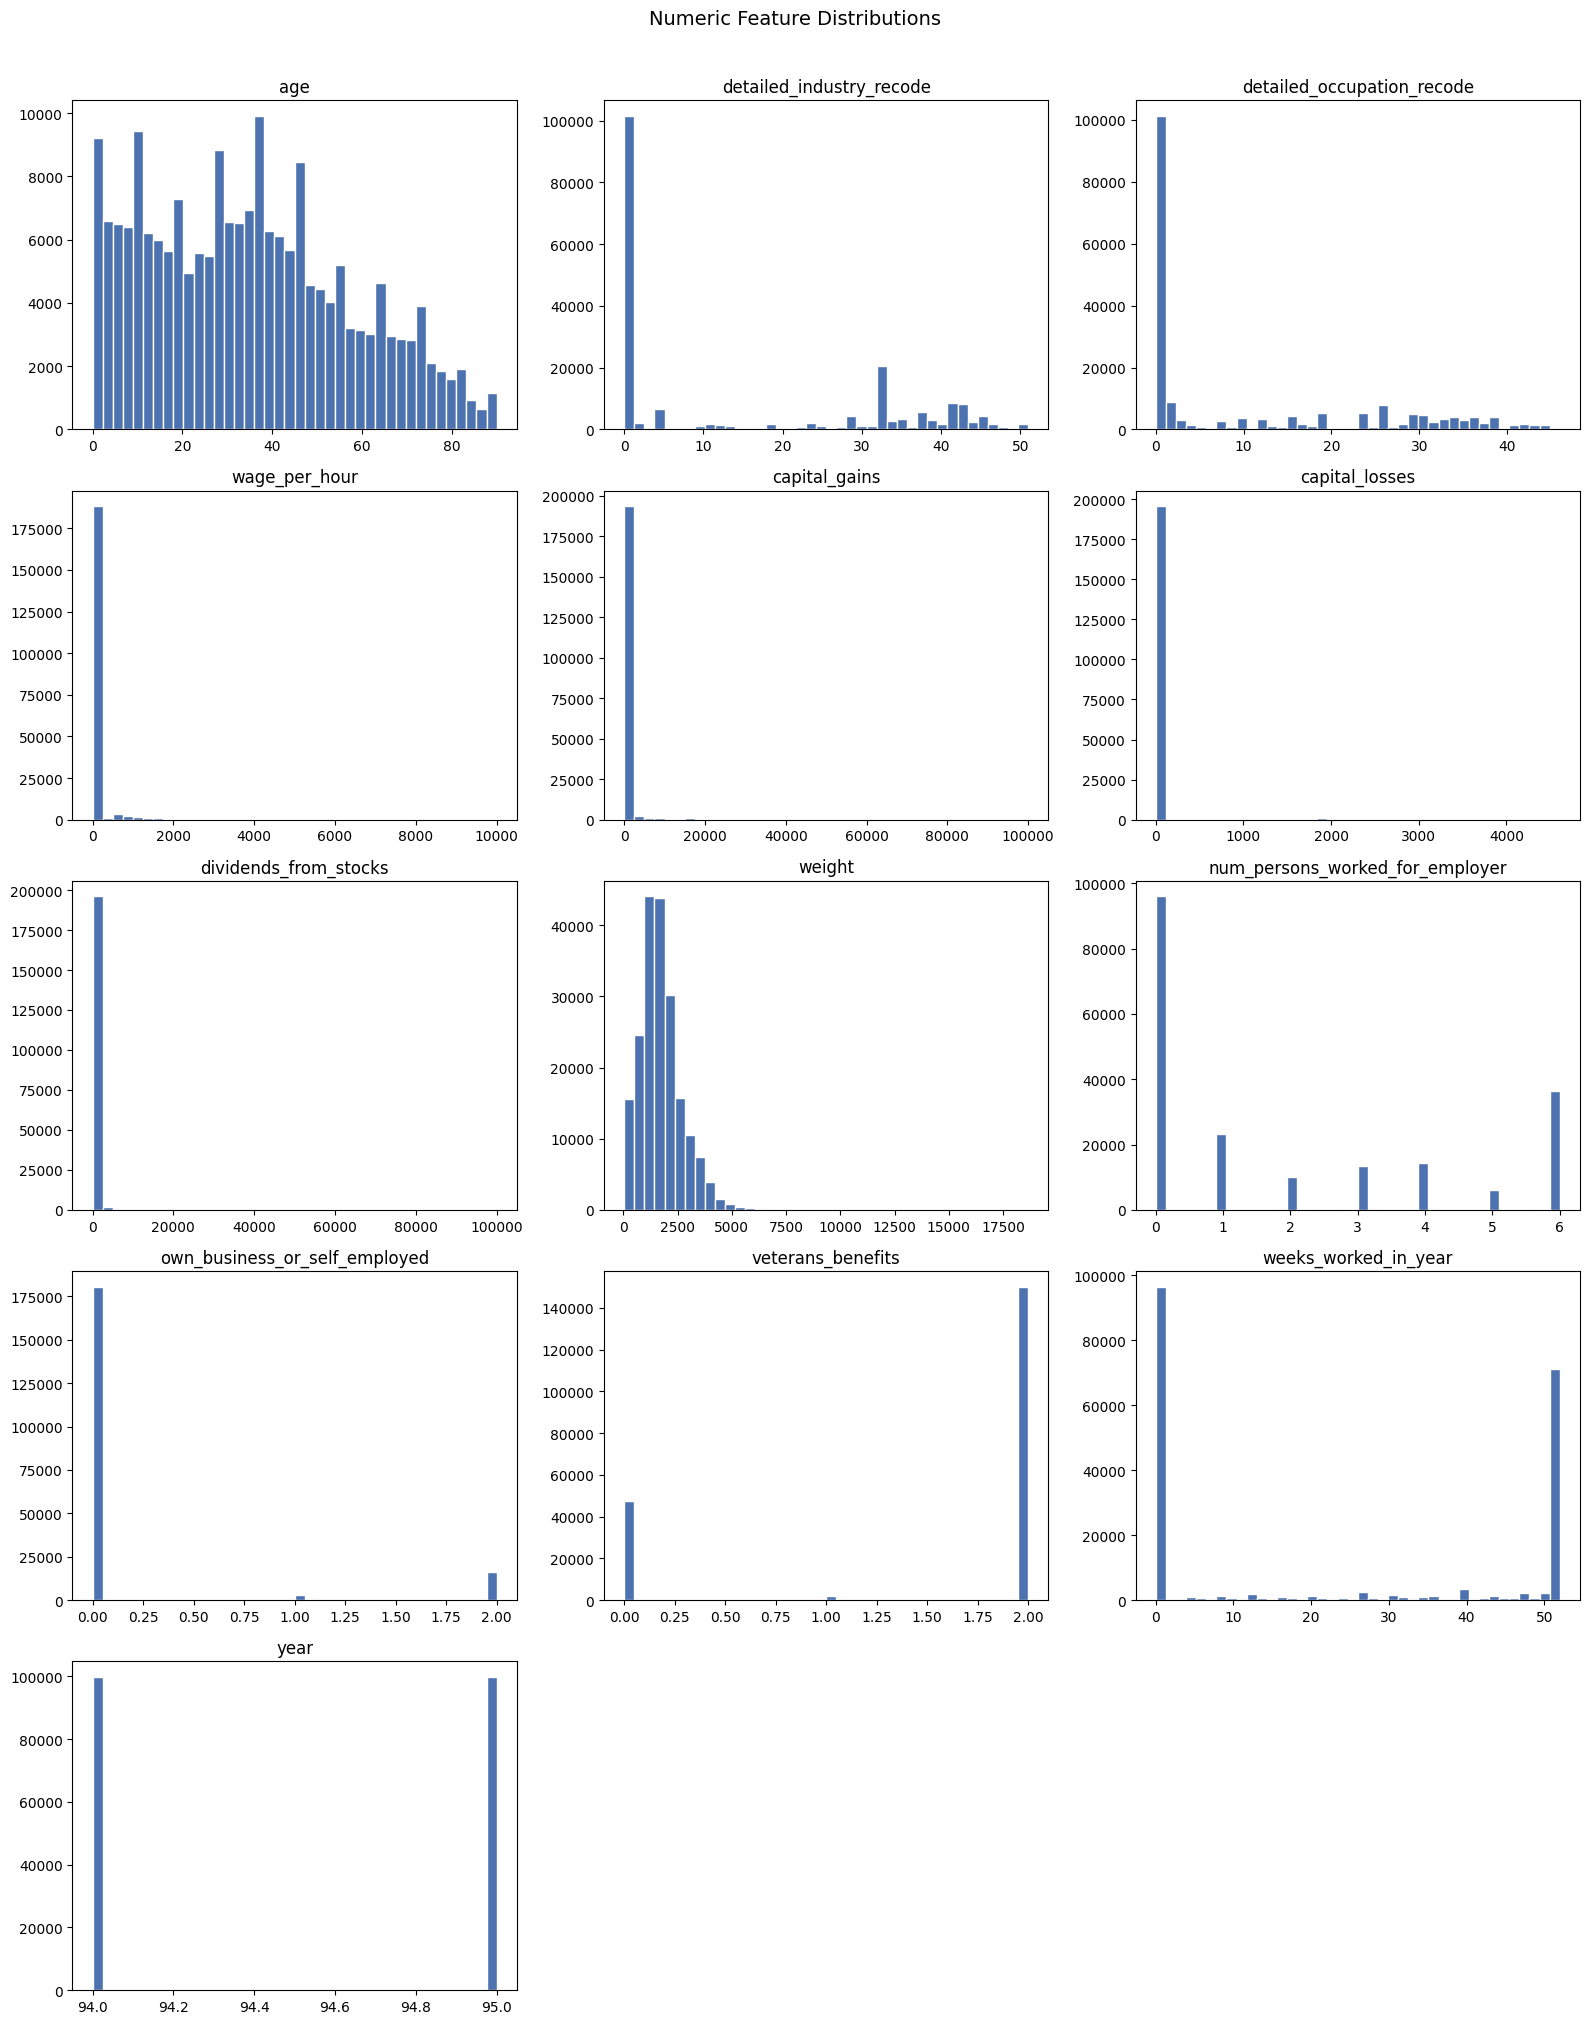

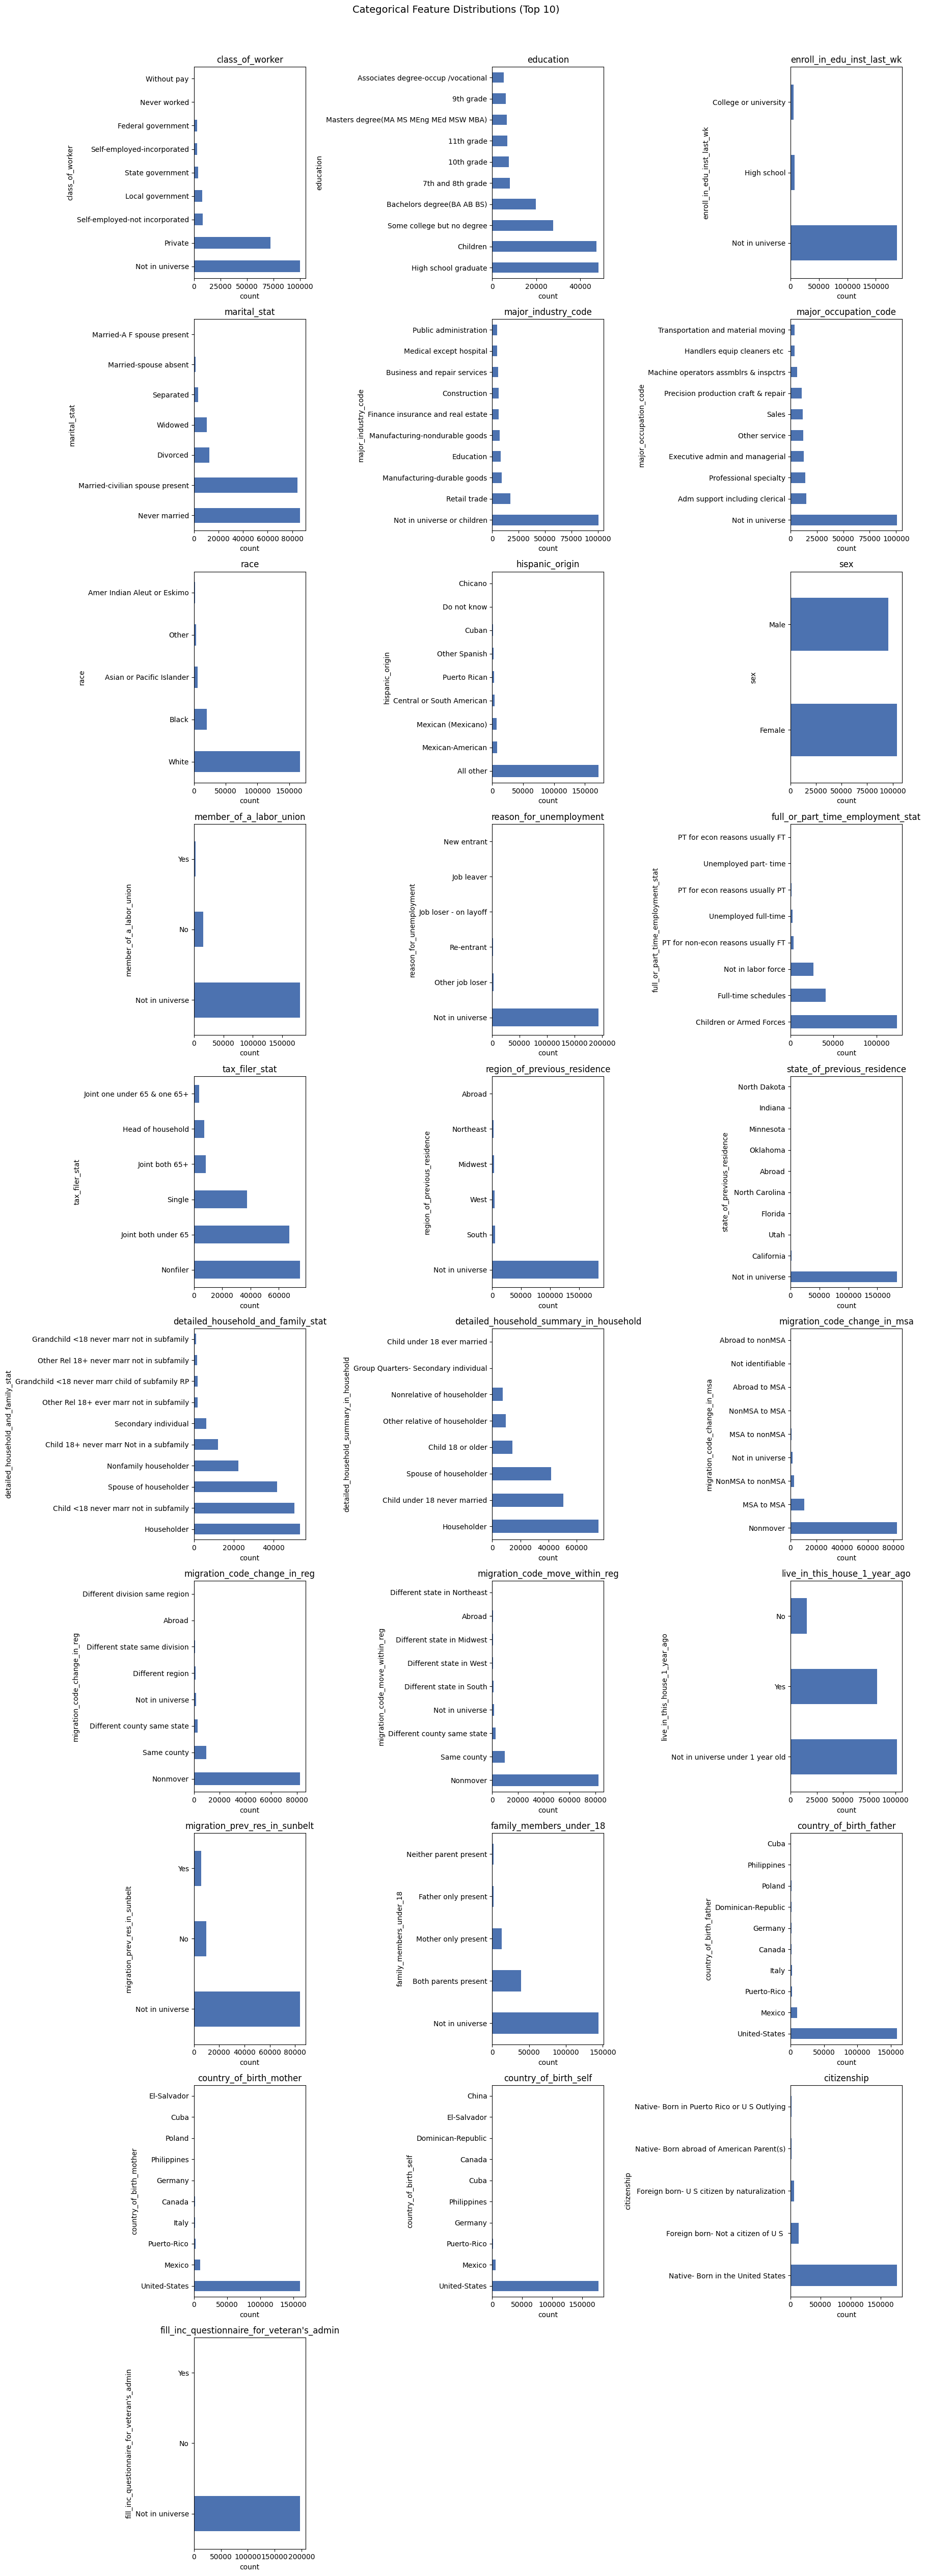

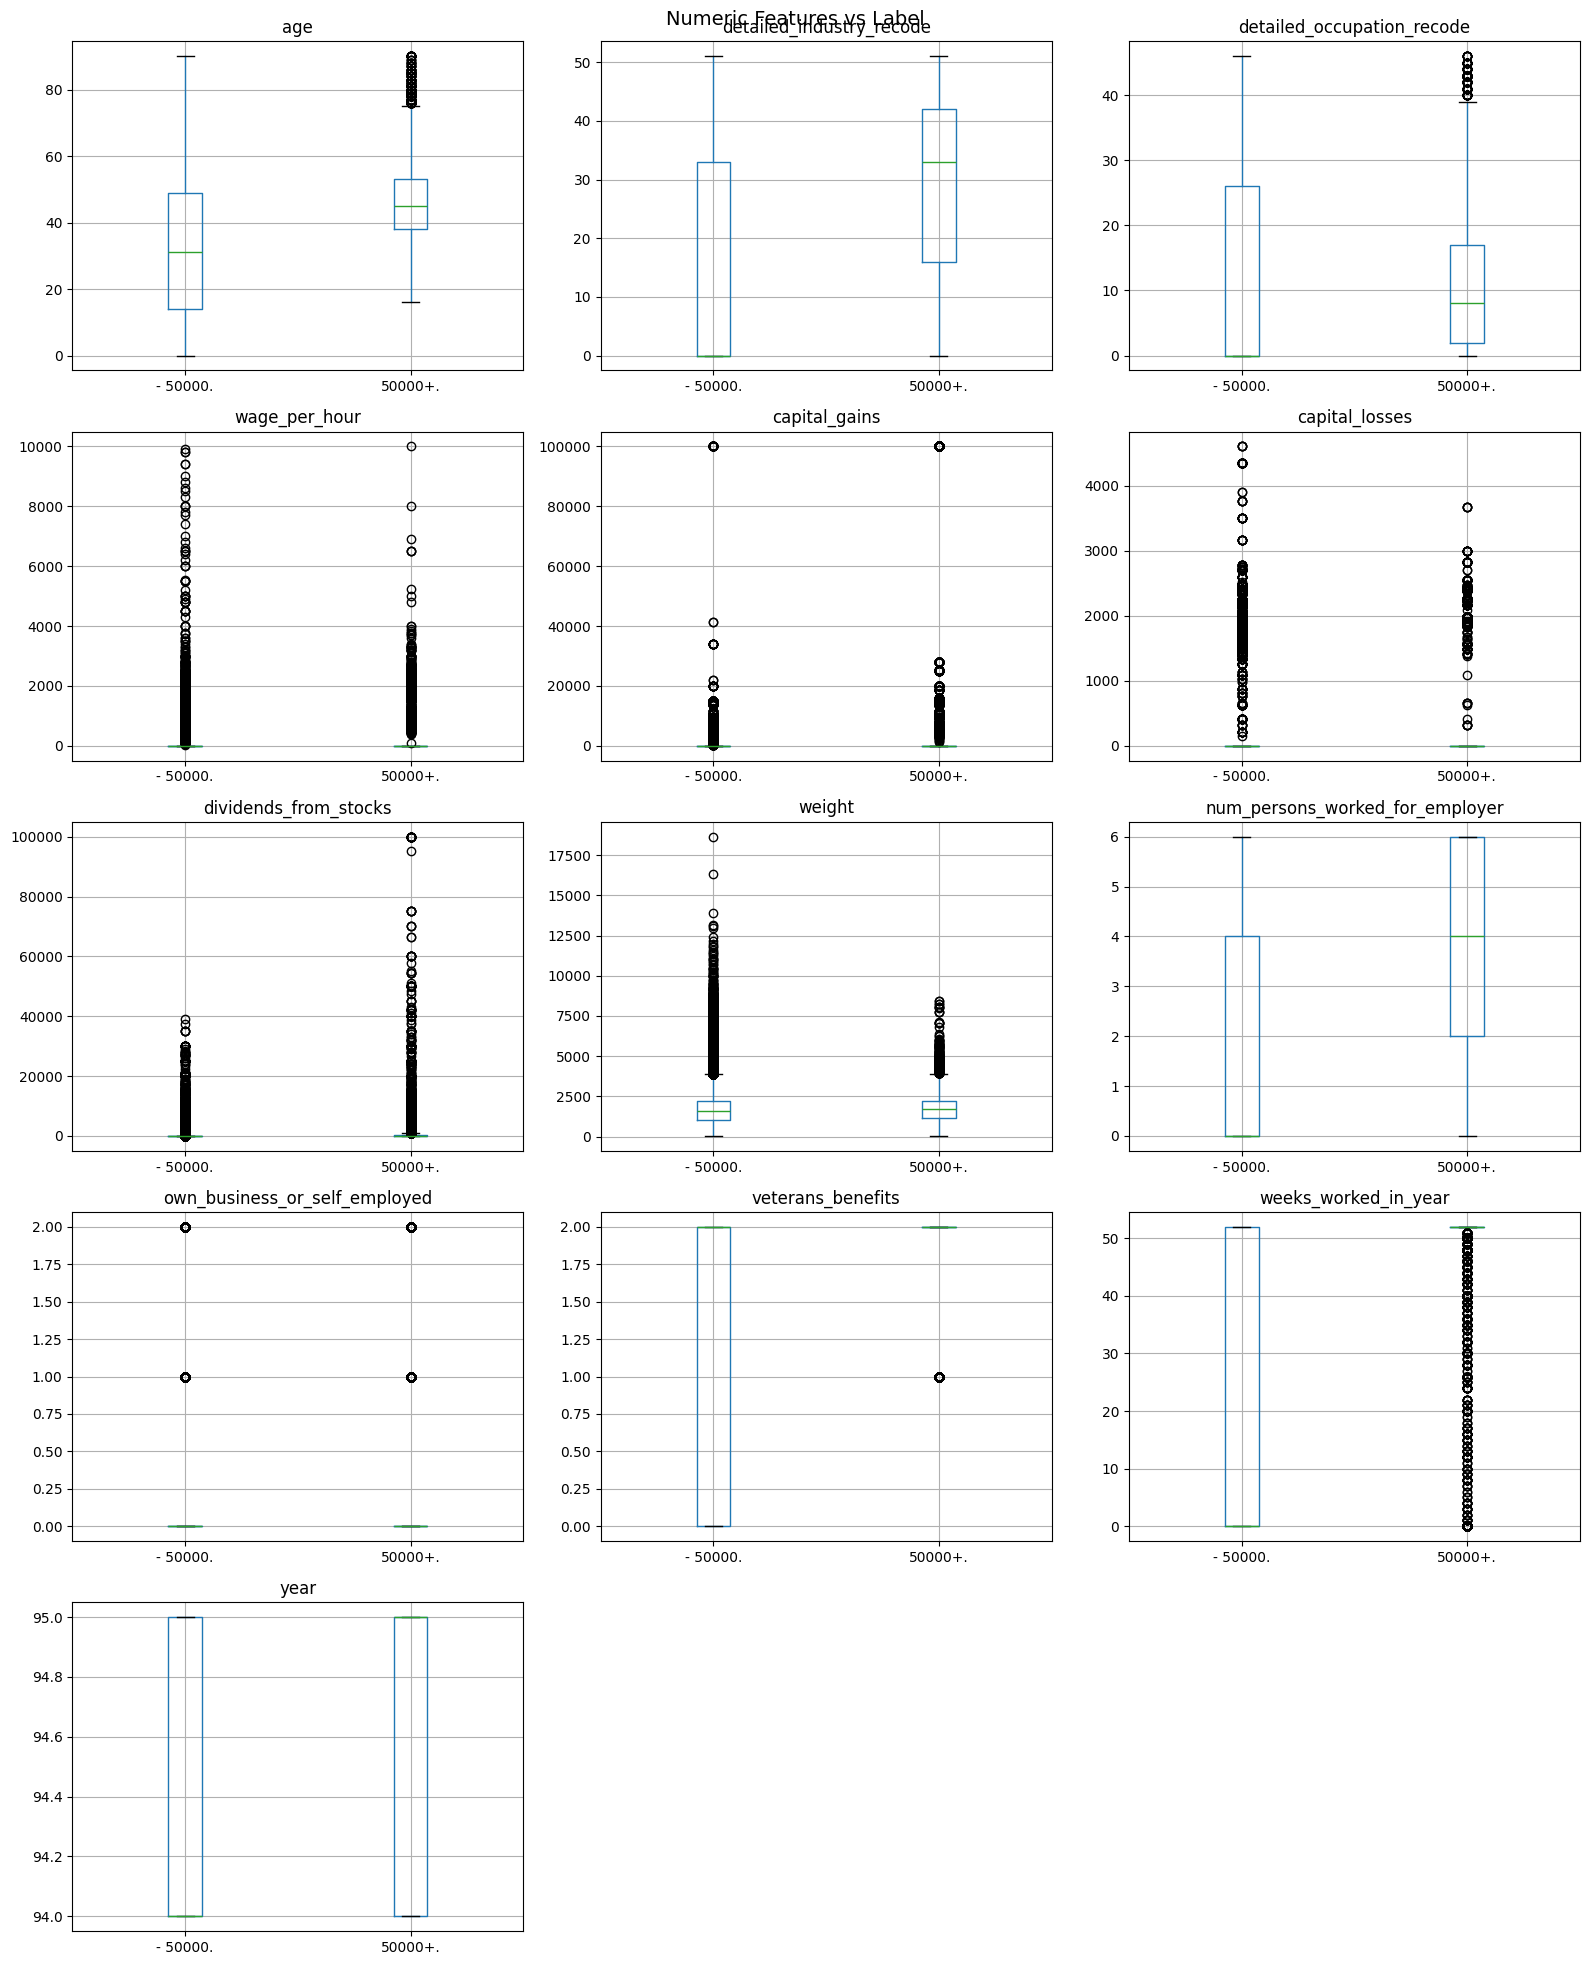

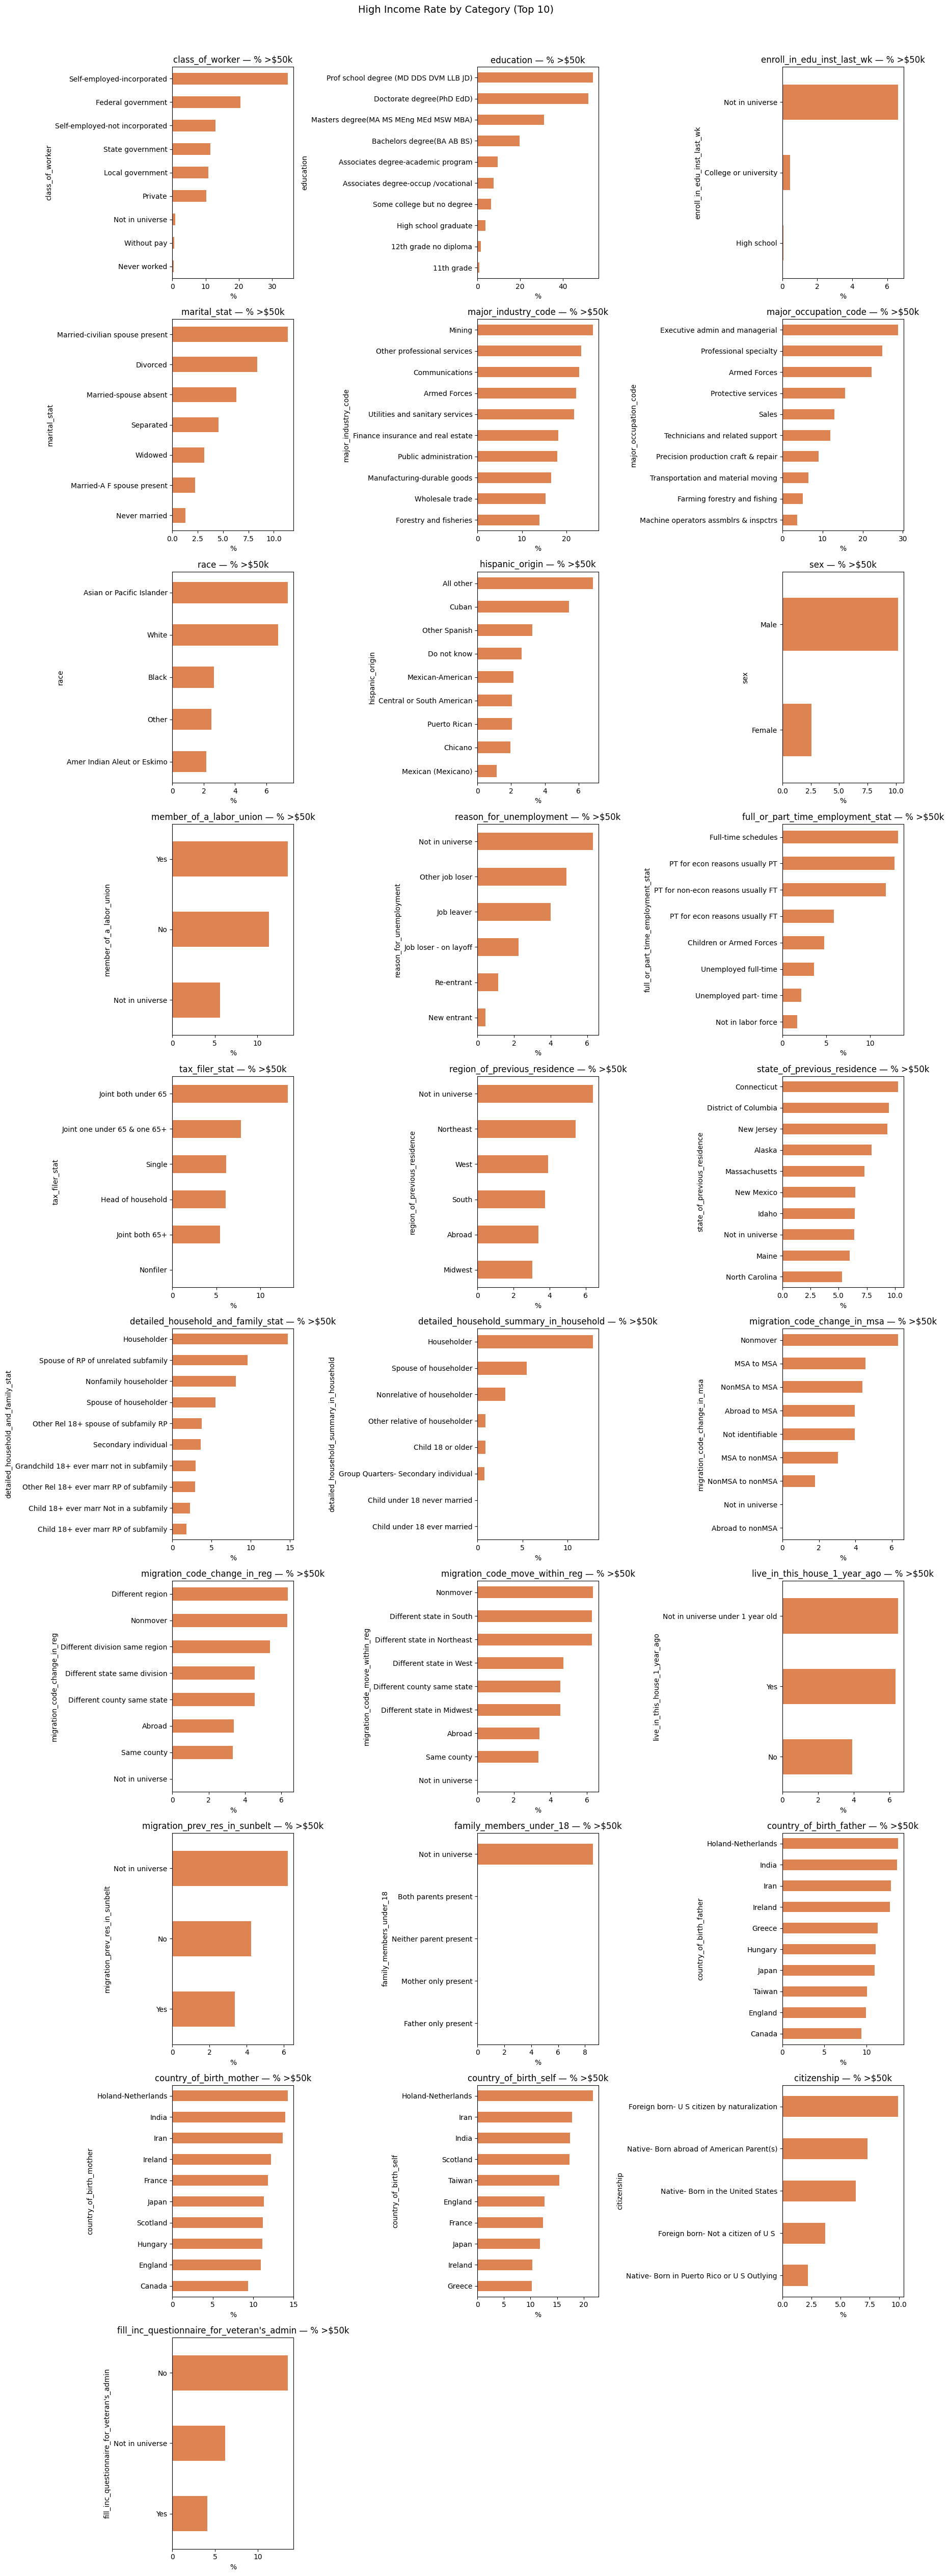

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

NUM_COLS = df.select_dtypes(include='number').columns.tolist()
CAT_COLS = df.select_dtypes(exclude='number').columns.tolist()
CAT_COLS = [c for c in CAT_COLS if c != 'label']

# ── 1. Numeric features
n = len(NUM_COLS)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(16, (n + 2) // 3 * 4))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    axes[i].hist(df[col].dropna(), bins=40, color='#4C72B0', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# ── 2. Categorical features
n = len(CAT_COLS)
fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(18, (n + 2) // 3 * 5))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    val_counts = df[col].value_counts().head(10)  # show top 10 only
    val_counts.plot(kind='barh', ax=axes[i], color='#4C72B0')
    axes[i].set_title(col)
    axes[i].set_xlabel('count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions (Top 10)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


# ── 3. Each variable vs income label
label = df['label']

# Numeric features
fig, axes = plt.subplots((len(NUM_COLS) + 2) // 3, 3, figsize=(16, (len(NUM_COLS) + 2) // 3 * 4))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    df.boxplot(column=col, by='label', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Features vs Label', fontsize=14)
plt.tight_layout()
plt.show()

# Categorical features
fig, axes = plt.subplots((len(CAT_COLS) + 2) // 3, 3, figsize=(18, (len(CAT_COLS) + 2) // 3 * 5))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    rate = df.groupby(col)['label'].apply(lambda x: (x == '50000+.').mean() * 100)
    rate.sort_values().tail(10).plot(kind='barh', ax=axes[i], color='#DD8452')
    axes[i].set_title(f'{col} — % >$50k')
    axes[i].set_xlabel('%')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('High Income Rate by Category (Top 10)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 1.6 Correlation Analysis

Identify highly correlated numeric features to detect redundancy.

**Key findings:**
- `detailed_industry_recode` ↔ `weeks_worked_in_year`: r = 0.75
- `detailed_occupation_recode` ↔ `weeks_worked_in_year`: r = 0.66

→ The `detailed_*` versions are **redundant** with their `major_*` counterparts and will be dropped.

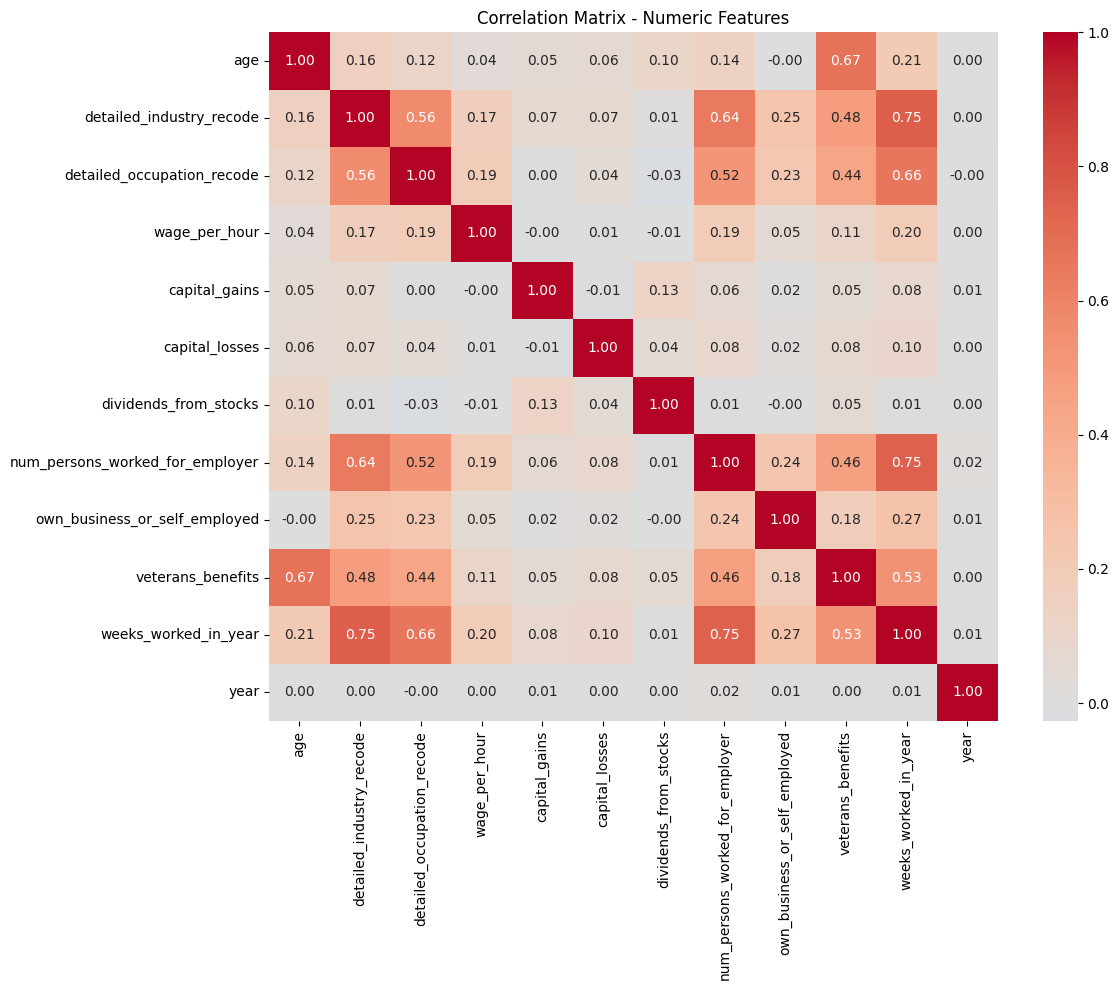

High correlation pairs (|corr| > 0.5):
                           var1                            var2  correlation
       detailed_industry_recode            weeks_worked_in_year     0.754472
num_persons_worked_for_employer            weeks_worked_in_year     0.747302
                            age               veterans_benefits     0.674844
     detailed_occupation_recode            weeks_worked_in_year     0.655613
       detailed_industry_recode num_persons_worked_for_employer     0.642096
       detailed_industry_recode      detailed_occupation_recode     0.563493
              veterans_benefits            weeks_worked_in_year     0.532279
     detailed_occupation_recode num_persons_worked_for_employer     0.515554


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

NUM_COLS = df.select_dtypes(include='number').columns.tolist()
NUM_COLS = [c for c in NUM_COLS if c != 'weight']  # weight is not a feature

corr = df[NUM_COLS].corr()

# heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Numeric Features')
plt.tight_layout()
plt.show()

threshold = 0.5
high_corr = (corr.abs()
               .where(lambda x: x < 1.0)
               .stack()
               .reset_index()
               .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'correlation'}))

high_corr = high_corr[high_corr['var1'] < high_corr['var2']]
high_corr = high_corr[high_corr['correlation'].abs() > threshold].sort_values('correlation', ascending=False)

print("High correlation pairs (|corr| > 0.5):")
print(high_corr.to_string(index=False))

### 1.7 Report-Quality EDA Figures (JPMC Style)

Generate publication-ready figures using the JPMC brand color palette for the final report:
- **Fig 1:** Income label distribution (class imbalance)
- **Fig 2:** Missing values by column
- **Fig 3:** Leakage assessment — `tax_filer_stat` vs `wage_per_hour`
- **Fig 4:** High-income rate by selected variables

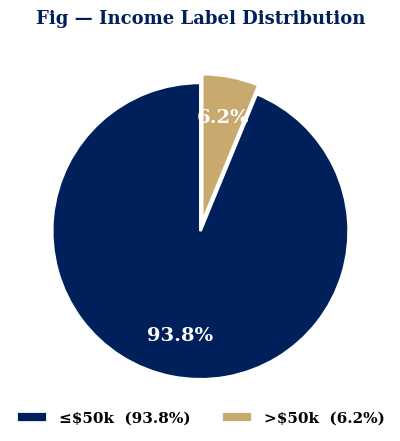

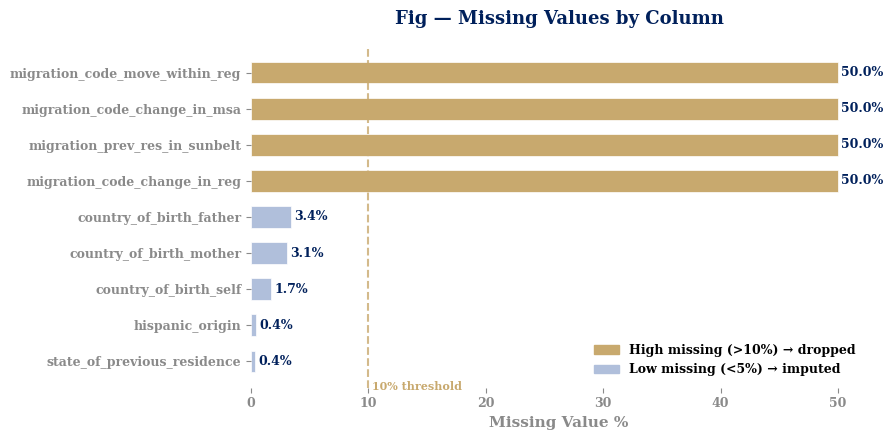

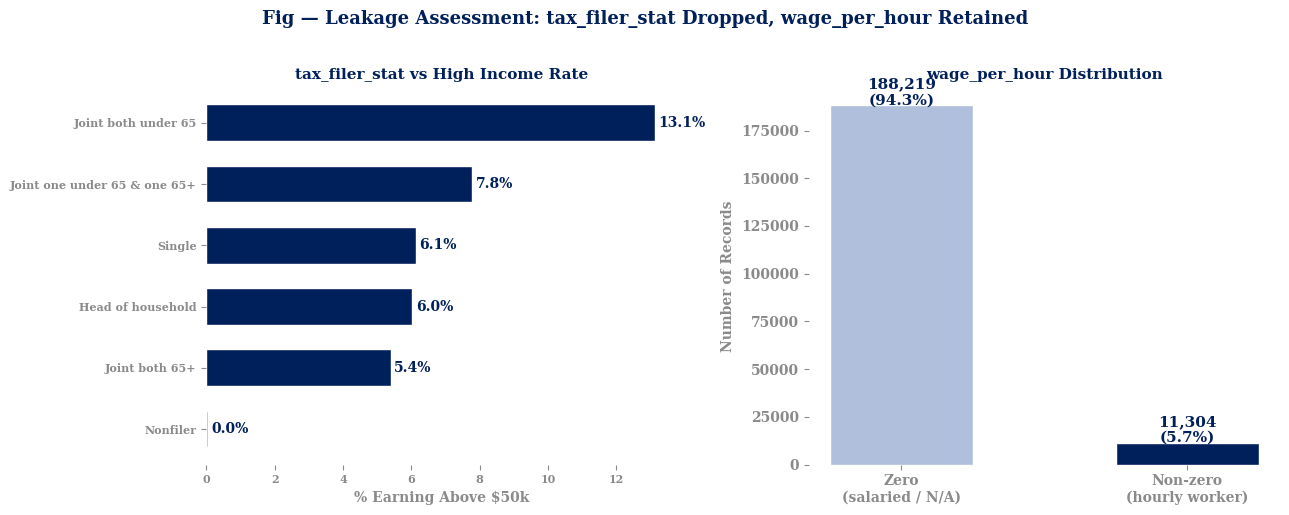

In [ ]:
NAVY  = "#00205B"
GOLD  = "#C8A96E"
LGOLD = "#F5EDD6"
LNAVY = "#B0BFDB"
MGRAY = "#8A8A8A"
WHITE = "#FFFFFF"
plt.rcParams.update({
    'font.family': 'DejaVu Serif',
    'font.weight': 'bold',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.grid': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# ── Fig 1: Label Distribution ─────────────────────────────────
low_pct  = (df[cols[-1]] == '- 50000.').mean() * 100
high_pct = (df[cols[-1]] == '50000+.').mean()  * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
sizes   = [low_pct, high_pct]
colors  = [NAVY, GOLD]
explode = (0, 0.06)

wedges, texts, autotexts = ax.pie(
    sizes, labels=None, colors=colors, explode=explode,
    autopct='%1.1f%%', startangle=90, pctdistance=0.72,
    wedgeprops=dict(linewidth=2, edgecolor='white')
)
for at in autotexts:
    at.set_fontsize(14)
    at.set_fontweight('bold')
    at.set_color('white')

ax.legend(wedges,
          [f'≤$50k  ({low_pct:.1f}%)', f'>$50k  ({high_pct:.1f}%)'],
          loc='lower center', bbox_to_anchor=(0.5, -0.06),
          ncol=2, fontsize=11, frameon=False)
ax.set_title('Fig — Income Label Distribution',
             fontsize=13, fontweight='bold', color=NAVY, pad=16)

plt.tight_layout()
plt.savefig('fig1_label_distribution.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()
# ── Fig 2: Missing Values ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))

missing = (df.isnull().sum() / len(df) * 100)
missing = missing[missing > 0].sort_values(ascending=True)

bar_colors = [GOLD if v > 10 else LNAVY for v in missing.values]
ax.barh(missing.index, missing.values,
        color=bar_colors, edgecolor='white', linewidth=0.5, height=0.6)

for i, (idx, val) in enumerate(missing.items()):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center',
            fontsize=9, color=NAVY, fontweight='bold')

ax.axvline(10, color=GOLD, linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(10.3, -0.8, '10% threshold', fontsize=8, color=GOLD, fontweight='bold')
ax.set_xlabel('Missing Value %', fontsize=11, color=MGRAY, fontweight='bold')
ax.set_title('Fig — Missing Values by Column',
             fontsize=13, fontweight='bold', color=NAVY, pad=16)
ax.tick_params(colors=MGRAY, labelsize=9)

legend_patches = [
    mpatches.Patch(color=GOLD,  label='High missing (>10%) → dropped'),
    mpatches.Patch(color=LNAVY, label='Low missing (<5%) → imputed'),
]
ax.legend(handles=legend_patches, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('fig2_missing_values.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()


# ── Fig 3: Leakage Assessment ─────────────────────────────────
df['high_income'] = (df['label'].str.strip() == '50000+.').astype(int)
total = len(df)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: tax_filer_stat
tax_rates = df.groupby('tax_filer_stat')['high_income'].mean() * 100
tax_rates = tax_rates.sort_values(ascending=True)

bar_colors_tax = [GOLD if v < 1 else NAVY for v in tax_rates.values]
axes[0].barh(tax_rates.index, tax_rates.values,
             color=bar_colors_tax, edgecolor='white', height=0.6)
for i, (idx, val) in enumerate(tax_rates.items()):
    axes[0].text(val + 0.1, i, f'{val:.1f}%', va='center',
                 fontsize=10, fontweight='bold', color=NAVY)

axes[0].set_xlabel('% Earning Above $50k', color=MGRAY, fontsize=10, fontweight='bold')
axes[0].set_title('tax_filer_stat vs High Income Rate',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[0].tick_params(colors=MGRAY, labelsize=8)

# Right: wage_per_hour
total      = len(df)
zero_wage  = (df['wage_per_hour'] == 0).sum()
nzero_wage = total - zero_wage

bars = axes[1].bar(
    ['Zero\n(salaried / N/A)', 'Non-zero\n(hourly worker)'],
    [zero_wage, nzero_wage],
    color=[LNAVY, NAVY], edgecolor='white', width=0.5
)
for bar, val in zip(bars, [zero_wage, nzero_wage]):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 500,
                 f'{val:,}\n({val/total*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold', color=NAVY)

axes[1].set_ylabel('Number of Records', color=MGRAY, fontsize=10, fontweight='bold')
axes[1].set_title('wage_per_hour Distribution',
                  fontsize=11, fontweight='bold', color=NAVY)
axes[1].tick_params(colors=MGRAY)

fig.suptitle('Fig — Leakage Assessment: tax_filer_stat Dropped, wage_per_hour Retained',
             fontsize=13, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig('fig3_leakage_assessment.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

### 1.8 Variable Separation Analysis

Compare how strongly asset ownership and behavioral variables separate income groups vs. traditional demographic variables.

This informs which variables to prioritize in feature engineering.

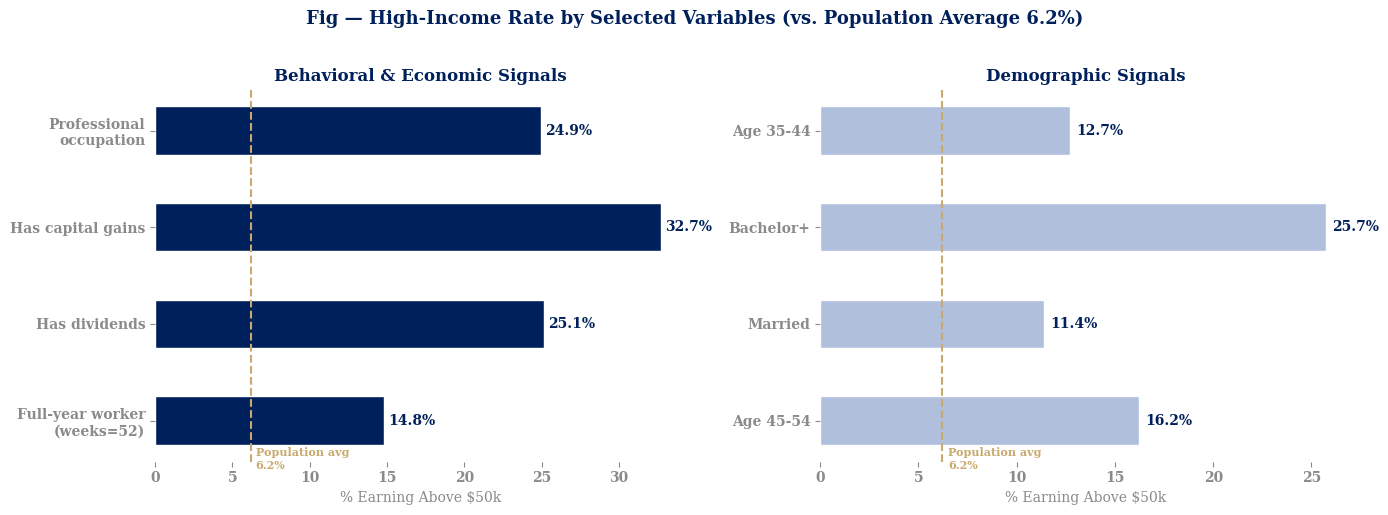

In [ ]:
# ── EDA: Behavioral vs Demographic signals ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['high_income'] = (df['label'].str.strip() == '50000+.').astype(int)
# behavioral variables vs high income rate
behavioral = {
    'Full-year worker\n(weeks=52)': df[df['weeks_worked_in_year']==52]['high_income'].mean() * 100,
    'Has dividends': df[df['dividends_from_stocks']>0]['high_income'].mean() * 100,
    'Has capital gains': df[df['capital_gains']>0]['high_income'].mean() * 100,
    'Professional\noccupation': df[df['major_occupation_code'].str.strip()=='Professional specialty']['high_income'].mean() * 100,
}

# demographic variables vs high income rate
demographic = {
    'Age 45-54': df[(df['age']>=45)&(df['age']<55)]['high_income'].mean() * 100,
    'Married': df[df['marital_stat'].str.strip()=='Married-civilian spouse present']['high_income'].mean() * 100,
    'Bachelor+': df[df['education'].str.strip().isin(['Bachelors degree(BA AB BS)','Masters degree(MA MS MEng MEd MSW MBA)','Doctorate degree(PhD EdD)','Prof school degree (MD DDS DVM LLB JD)'])]['high_income'].mean() * 100,
    'Age 35-44': df[(df['age']>=35)&(df['age']<45)]['high_income'].mean() * 100,
}


for ax, data, title, color in zip(
    axes,
    [behavioral, demographic],
    ['Behavioral & Economic Signals', 'Demographic Signals'],
    [NAVY, LNAVY]
):
    bars = ax.barh(list(data.keys()), list(data.values()),
                   color=color, edgecolor='white', height=0.5)
    for bar, val in zip(bars, data.values()):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10,
                fontweight='bold', color=NAVY)
    ax.axvline(df['high_income'].mean()*100, color=GOLD,
               linestyle='--', linewidth=1.5)
    ax.text(df['high_income'].mean()*100 + 0.3, -0.5,
            f'Population avg\n{df["high_income"].mean()*100:.1f}%',
            fontsize=8, color=GOLD, fontweight='bold')
    ax.set_xlabel('% Earning Above $50k', color=MGRAY, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', color=NAVY)
    ax.tick_params(colors=MGRAY)

fig.suptitle('Fig — High-Income Rate by Selected Variables (vs. Population Average 6.2%)',
             fontsize=13, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig('fig4_behavioral_vs_demographic.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

### 1.9 Leakage Deep-Dive: `tax_filer_stat` vs `wage_per_hour`

**Finding 3 (leakage risk):** `tax_filer_stat` shows a 0% high-income rate for 'Nonfiler' — it encodes income as a behavioral consequence, not an independent predictor.

`wage_per_hour` might appear similar but is 94.3% zero (salaried employees) — it captures employment type, not income level, so it is **retained**.

In [ ]:
# ── wage_per_hour vs label ────────────────────────────────────
print("wage_per_hour vs high income:")
print(df.groupby('high_income')['wage_per_hour'].describe())
print(f"\nAvg wage (low income):  ${df[df['high_income']==0]['wage_per_hour'].mean():.2f}/hr")
print(f"Avg wage (high income): ${df[df['high_income']==1]['wage_per_hour'].mean():.2f}/hr")

# ── tax_filer_stat vs label ───────────────────────────────────
print("\ntax_filer_stat vs high income rate:")
tax_rates = df.groupby('tax_filer_stat')['high_income'].mean() * 100
print(tax_rates.sort_values(ascending=False).round(1))

wage_per_hour vs high income:
                count       mean         std  min  25%  50%  75%     max
high_income                                                             
0            187141.0  53.692526  261.168380  0.0  0.0  0.0  0.0  9916.0
1             12382.0  81.640284  431.364773  0.0  0.0  0.0  0.0  9999.0

Avg wage (low income):  $53.69/hr
Avg wage (high income): $81.64/hr

tax_filer_stat vs high income rate:
tax_filer_stat
Joint both under 65             13.1
Joint one under 65 & one 65+     7.8
Single                           6.1
Head of household                6.0
Joint both 65+                   5.4
Nonfiler                         0.0
Name: high_income, dtype: float64


### 1.10 Clean Up EDA Artifacts

Remove temporary columns created during EDA (e.g. `high_income`) before preprocessing begins. These must not enter the feature matrix as they would cause data leakage.

In [ ]:
# clean up EDA artifacts before preprocessing
df.drop(columns=['high_income'], inplace=True, errors='ignore')

---

## Part II: Preprocessing

**Goal:** Transform raw census data into a clean, model-ready feature matrix.

**Key decisions made based on EDA findings:**
- Drop columns with irrecoverable missingness, redundancy, or leakage risk
- Engineer new features to better capture known signals
- Handle class imbalance with three complementary strategies

| Step | What | Why |
|------|------|-----|
| 1 | Separate target & weights | `weight` is sampling metadata, not a feature |
| 2 | Create `is_us_born` before dropping source columns | Derived feature must be created before source columns are removed |
| 3 | Drop columns | Missingness, redundancy, leakage |
| 4 | Deduplicate + filter adults ≥18 | Remove noise, align with marketing target |
| 5 | Binary flags for zero-inflated columns | `has_capital_gains` etc. capture asset ownership independently |
| 6 | Discretize `weeks_worked` | Bimodal distribution → 3 meaningful categories |
| 7 | Simplify high-cardinality categoricals | Reduce noise while preserving signal |
| 8 | Impute remaining missing values | Median for numeric, 'Unknown' for categorical |
| 9 | Label Encoding | Tree models don't assume ordinality from integer codes |
| 10 | Sanity check | Verify shape, NaN count, and class balance |

In [ ]:
# ── 1. Separate target & weight before any processing ─────────
# weight is a census sampling design variable, not a feature.
# stored separately and passed to models as sample_weight later.
weights = df['weight'].copy()
y = (df['label'].str.strip() == '50000+.').astype(int)
print(f"class balance — high income (>$50k): {y.mean():.2%}")

# ── 2. Create derived features BEFORE dropping source columns ─
# is_us_born: consolidate 3 country-of-birth columns into one flag.
# must be created before the source columns are dropped in step 3.
df['is_us_born'] = (
    (df['country_of_birth_self'].str.strip()   == 'United-States') &
    (df['country_of_birth_father'].str.strip() == 'United-States') &
    (df['country_of_birth_mother'].str.strip() == 'United-States')
).astype(int)

# ── 3. Drop columns ───────────────────────────────────────────
# Criteria: irrecoverable missingness, redundancy, no signal, leakage.
# Correlation analysis showed detailed_industry_recode (r=0.75) and
# detailed_occupation_recode (r=0.66) are highly correlated with
# weeks_worked_in_year and redundant with their major_* counterparts.
DROP_COLS = [
    'label', 'weight', 'year',

    # migration / residence
    'migration_code_change_in_msa',
    'migration_code_change_in_reg',
    'migration_code_move_within_reg',
    'migration_prev_res_in_sunbelt',
    'region_of_previous_residence',
    'state_of_previous_residence',
    'live_in_this_house_1_year_ago',

    # redundant
    'detailed_industry_recode',
    'detailed_occupation_recode',
    'detailed_household_and_family_stat',

    # country of birth: consolidated into is_us_born above
    'country_of_birth_father',
    'country_of_birth_mother',
    'country_of_birth_self',

    # almost entirely 'Not in universe'
    "fill_inc_questionnaire_for_veteran's_admin",

    # direct leakage
    'tax_filer_stat',
]
X = df.drop(columns=DROP_COLS).copy()
print(f"features after dropping: {X.shape[1]}")

# ── 4. Remove duplicates then filter to adults ────────────────
# 2,839 records have age=0 — these are children/dependents in the
# census whose income is zero by definition, not by economic pattern.
# Excluding them aligns the modeling population with the marketing target.
before = len(X)
X.drop_duplicates(inplace=True)
y       = y[X.index]
weights = weights[X.index]
print(f"dropped {before - len(X):,} duplicates")

mask    = X['age'] >= 18
X       = X[mask].copy()
y       = y[mask]
weights = weights[mask]
print(f"remaining after adult filter: {len(X):,}")

# ── 5. Binary flags for zero-inflated numeric columns ─────────
# These columns are 90-96% zeros, but non-zero values are strongly
# associated with high income (e.g. capital_gains: 32.7% vs 5.2%).
# Adding binary flags captures asset ownership as a separate signal
# alongside the raw amount.
ZERO_INFLATED = ['capital_gains', 'capital_losses',
                 'dividends_from_stocks', 'wage_per_hour']
for col in ZERO_INFLATED:
    X[f'has_{col}'] = (X[col] > 0).astype(int)

# ── 6. weeks_worked_in_year → 3-category variable ────────────
# Distribution is strongly bimodal: most records are 0 or 52 weeks.
# Treating this as continuous misrepresents its nature —
# the meaningful distinction is the type of worker, not the exact count.
X['weeks_worked_cat'] = pd.cut(
    X['weeks_worked_in_year'],
    bins=[-1, 0, 51, 52],
    labels=['none', 'partial', 'full']
)
X = X.drop(columns=['weeks_worked_in_year'])

# ── 7. Simplify high-cardinality / skewed categorical columns ─
# citizenship: simplify to binary citizen vs. non-citizen
X['citizenship'] = X['citizenship'].fillna('Unknown')
X['is_citizen']  = X['citizenship'].str.strip().apply(
    lambda x: 0 if 'Not a citizen' in x else 1
)
X = X.drop(columns=['citizenship'])

# hispanic_origin: 95% 'All other' — simplify to binary flag
X['hispanic_origin'] = X['hispanic_origin'].fillna('All other')
X['is_hispanic']     = X['hispanic_origin'].str.strip().apply(
    lambda x: 0 if x == 'All other' else 1
)
X = X.drop(columns=['hispanic_origin'])

# ── 8. Fill remaining missing values ─────────────────────────
# numeric: fill with median (robust to outliers)
# categorical: fill with 'Unknown' ('Not in universe' is kept as-is
#              since it meaningfully encodes non-applicability)
NUM_COLS = X.select_dtypes(include='number').columns.tolist()
for col in NUM_COLS:
    X[col] = X[col].fillna(X[col].median())

CAT_COLS = X.select_dtypes(exclude='number').columns.tolist()
for col in CAT_COLS:
    if hasattr(X[col], 'cat'):
        X[col] = X[col].cat.add_categories('Unknown')
    X[col] = X[col].fillna('Unknown')

# ── 9. Encode categorical variables ──────────────────────────
# Label encoding is appropriate here: tree-based models (RF, XGBoost)
# do not assume ordinality from integer-encoded categories.
le_dict = {}
for col in CAT_COLS:
    le          = LabelEncoder()
    X[col]      = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# ── 10. Sanity check ──────────────────────────────────────────
import pandas as pd
from IPython.display import display

# shape & NaN
summary = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Remaining NaNs', 'High income (>$50k)', 'Low income (≤$50k)'],
    'Value':  [
        f"{X.shape[0]:,}",
        f"{X.shape[1]}",
        f"{X.isnull().sum().sum()}",
        f"{(y==1).sum():,}  ({y.mean():.1%})",
        f"{(y==0).sum():,}  ({1-y.mean():.1%})"
    ]
})
display(summary.style
    .set_caption("Preprocessing Summary")
    .hide(axis='index')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#00205B'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f5f5f5')]},
    ])
)

# feature list
feat_df = pd.DataFrame({
    '#':       range(1, X.shape[1]+1),
    'Feature': X.columns.tolist(),
    'Type':    ['numeric' if X[c].dtype in ['int64','float64'] else 'categorical' for c in X.columns],
    'Nulls':   [X[c].isnull().sum() for c in X.columns]
})
display(feat_df.style
    .set_caption("Feature List")
    .hide(axis='index')
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#00205B'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f5f5f5')]},
    ])
    .apply(lambda x: ['color: #C8A96E; font-weight: bold' if v == 'numeric'
                      else 'color: #1A3A5C' for v in x], subset=['Type'])
)

class balance — high income (>$50k): 6.21%
features after dropping: 25
dropped 60,689 duplicates
remaining after adult filter: 129,307


Metric,Value
Rows,"129,307"
Columns,29
Remaining NaNs,0
High income (>$50k),"12,240 (9.5%)"
Low income (≤$50k),"117,067 (90.5%)"


#,Feature,Type,Nulls
1,age,numeric,0
2,class_of_worker,numeric,0
3,education,numeric,0
4,wage_per_hour,numeric,0
5,enroll_in_edu_inst_last_wk,numeric,0
6,marital_stat,numeric,0
7,major_industry_code,numeric,0
8,major_occupation_code,numeric,0
9,race,numeric,0
10,sex,numeric,0


### Preprocessing Summary

Verify the final dataset before modeling:
- No remaining NaN values
- Class balance reflects true population (higher than raw data — children removed)
- Feature count is as expected

In [ ]:
print(f"After Preprocessing - class balance:")
print(f"  ≤$50k : {(y==0).sum():>8,}  ({(y==0).mean():.2%})")
print(f"  >$50k : {(y==1).sum():>8,}  ({(y==1).mean():.2%})")
print(f"  Total : {len(y):>8,}")

After Preprocessing - class balance:
  ≤$50k :  117,067  (90.53%)
  >$50k :   12,240  (9.47%)
  Total :  129,307


### Feature List Verification

Confirm all expected features are present and correctly typed.

In [ ]:
print(X.columns.tolist())

['age', 'class_of_worker', 'education', 'wage_per_hour', 'enroll_in_edu_inst_last_wk', 'marital_stat', 'major_industry_code', 'major_occupation_code', 'race', 'sex', 'member_of_a_labor_union', 'reason_for_unemployment', 'full_or_part_time_employment_stat', 'capital_gains', 'capital_losses', 'dividends_from_stocks', 'detailed_household_summary_in_household', 'num_persons_worked_for_employer', 'family_members_under_18', 'own_business_or_self_employed', 'veterans_benefits', 'is_us_born', 'has_capital_gains', 'has_capital_losses', 'has_dividends_from_stocks', 'has_wage_per_hour', 'weeks_worked_cat', 'is_citizen', 'is_hispanic']


---

## Part III: Income Classification Model

**Goal:** Predict which prospects are likely to earn above \$50k annually.

**Modeling pipeline:**
1. 80/20 stratified train/test split
2. Train baseline models (Logistic Regression, Random Forest)
3. Tune XGBoost with RandomizedSearchCV
4. Optimize decision threshold using precision-recall curve
5. Evaluate final model on held-out test set

**Primary metric:** AUC-ROC (robust to class imbalance, threshold-independent)

**Imbalance handling:** Three simultaneous strategies:
- `sample_weight`: census population weights → ensures predictions reflect true U.S. population
- `class_weight='balanced_subsample'`: Random Forest bootstrap balancing
- `scale_pos_weight=9.56`: XGBoost minority class upweighting

### 3.1 Train/Test Split + Baseline Models

Split data 80/20 (stratified to preserve 9.47% positive rate), then train Logistic Regression and Random Forest as baselines.

**Why these baselines?**
- Logistic Regression: establishes whether the problem is linearly separable
- Random Forest: handles nonlinear interactions without distributional assumptions

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             precision_recall_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import numpy as np

NAVY = "#00205B"
GOLD = "#C8A96E"
LNAVY = "#B0BFDB"
MGRAY = "#8A8A8A"

# ── 1. Train / Test Split ─────────────────────────────────────
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"train: {len(X_train):,}  |  test: {len(X_test):,}")
print(f"positive rate — train: {y_train.mean():.3f}  |  test: {y_test.mean():.3f}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

train: 103,445  |  test: 25,862
positive rate — train: 0.095  |  test: 0.095
scale_pos_weight: 9.56


### 3.2 XGBoost with Hyperparameter Tuning

XGBoost sequentially corrects residual errors of prior trees, capturing subtler interactions that ensemble averaging smooths out.

**Search space:** 30 random combinations from:
- `n_estimators`: [200, 400]
- `max_depth`: [4, 6, 8]
- `learning_rate`: [0.05, 0.1]
- `subsample`: [0.8, 1.0]
- `colsample_bytree`: [0.8, 1.0]
- `reg_lambda`: [1.0, 2.0]

**Cross-validation:** 3-fold StratifiedKFold, scored on AUC-ROC

In [ ]:
# ── 2. Baseline Models (LR + RF) ─────────────────────────────
results = {}

baseline_models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=3000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ),
}

for name, model in baseline_models.items():
    print(f"\n── {name} ──")
    model.fit(X_train, y_train, sample_weight=w_train)
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    auc  = roc_auc_score(y_test, prob, sample_weight=w_test)
    results[name] = {'model': model, 'prob': prob, 'pred': pred, 'auc': auc}
    print(f"AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, pred, target_names=['<=50k', '>50k']))


── Logistic Regression ──


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AUC-ROC: 0.8625
              precision    recall  f1-score   support

       <=50k       0.97      0.78      0.86     23414
        >50k       0.27      0.78      0.40      2448

    accuracy                           0.78     25862
   macro avg       0.62      0.78      0.63     25862
weighted avg       0.90      0.78      0.82     25862


── Random Forest ──
AUC-ROC: 0.9064
              precision    recall  f1-score   support

       <=50k       0.98      0.83      0.90     23414
        >50k       0.33      0.80      0.47      2448

    accuracy                           0.83     25862
   macro avg       0.66      0.82      0.69     25862
weighted avg       0.92      0.83      0.86     25862



In [ ]:
# ── 3. XGBoost with Hyperparameter Tuning ────────────────────
print("\n── XGBoost Hyperparameter Tuning ──")

param_grid = {
    'n_estimators':     [200, 400],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda':       [1.0, 2.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        verbosity=0,
        eval_metric='auc'
    ),
    param_distributions=param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train, sample_weight=w_train)
print(f"Best params: {search.best_params_}")
print(f"Best CV AUC: {search.best_score_:.4f}")

best_xgb = search.best_estimator_
xgb_prob = best_xgb.predict_proba(X_test)[:, 1]
xgb_pred = best_xgb.predict(X_test)
xgb_auc  = roc_auc_score(y_test, xgb_prob, sample_weight=w_test)

results['XGBoost'] = {
    'model': best_xgb, 'prob': xgb_prob,
    'pred': xgb_pred,  'auc': xgb_auc
}

print(f"\nTest AUC: {xgb_auc:.4f}")
print(classification_report(y_test, xgb_pred, target_names=['<=50k', '>50k']))


── XGBoost Hyperparameter Tuning ──
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'subsample': 1.0, 'reg_lambda': 2.0, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV AUC: 0.9253

Test AUC: 0.9273
              precision    recall  f1-score   support

       <=50k       0.98      0.85      0.91     23414
        >50k       0.37      0.83      0.51      2448

    accuracy                           0.85     25862
   macro avg       0.67      0.84      0.71     25862
weighted avg       0.92      0.85      0.87     25862



### 3.3 Threshold Optimization

The default 0.5 threshold is too aggressive here — XGBoost with `scale_pos_weight` outputs higher probabilities for the positive class.

**Method:** Find the threshold that maximizes F1 on the high-income class using the precision-recall curve.

**Trade-off:** Raising the threshold improves precision (fewer wasted contacts) at the cost of recall (some high-income prospects missed).

In [ ]:
# ── 4. Threshold Optimization ─────────────────────────────────
prec, rec, thr = precision_recall_curve(y_test, xgb_prob)
f1       = 2 * (prec * rec) / (prec + rec + 1e-9)
best_thr = thr[np.argmax(f1)]

y_pred_opt = (xgb_prob >= best_thr).astype(int)

print(f"\nBest threshold (max F1): {best_thr:.3f}")
print(f"\n── XGBoost default threshold (0.5) ──")
print(classification_report(y_test, xgb_pred, target_names=['<=50k', '>50k']))
print(f"\n── XGBoost optimized threshold ({best_thr:.3f}) ──")
print(classification_report(y_test, y_pred_opt, target_names=['<=50k', '>50k']))


Best threshold (max F1): 0.807

── XGBoost default threshold (0.5) ──
              precision    recall  f1-score   support

       <=50k       0.98      0.85      0.91     23414
        >50k       0.37      0.83      0.51      2448

    accuracy                           0.85     25862
   macro avg       0.67      0.84      0.71     25862
weighted avg       0.92      0.85      0.87     25862


── XGBoost optimized threshold (0.807) ──
              precision    recall  f1-score   support

       <=50k       0.96      0.96      0.96     23414
        >50k       0.61      0.61      0.61      2448

    accuracy                           0.93     25862
   macro avg       0.78      0.78      0.78     25862
weighted avg       0.93      0.93      0.93     25862



### 3.4 Model Comparison & Evaluation Figures

Compare all three models and visualize:
- **Fig A:** ROC curves (all models)
- **Fig B:** AUC comparison bar chart
- **Fig C:** Confusion matrix — default vs optimized threshold
- **Fig D:** Top 15 feature importances (XGBoost)

In [ ]:
# ── 5. Model Comparison Summary ──────────────────────────────
print("\n── Model Comparison ──")
summary = pd.DataFrame({
    name: {'AUC-ROC': res['auc']}
    for name, res in results.items()
}).T.sort_values('AUC-ROC', ascending=False)
print(summary.round(4))


── Model Comparison ──
                     AUC-ROC
XGBoost               0.9273
Random Forest         0.9064
Logistic Regression   0.8625


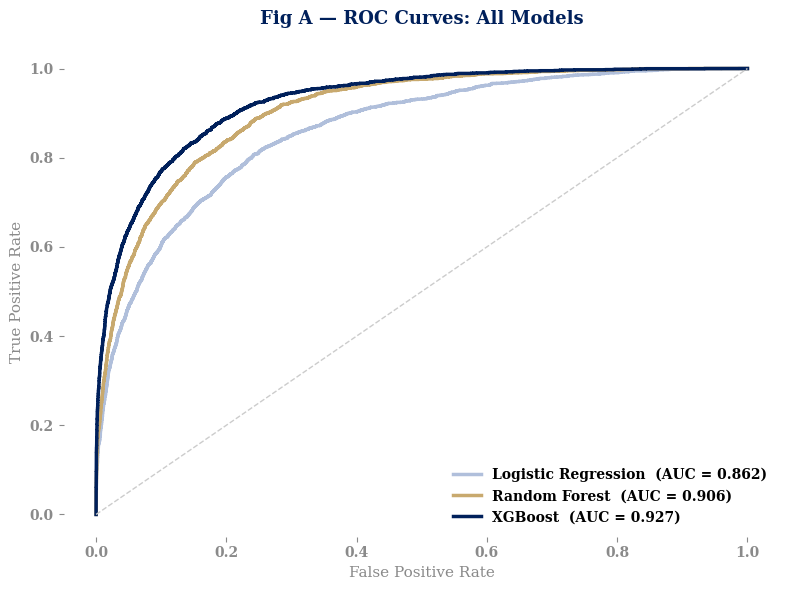

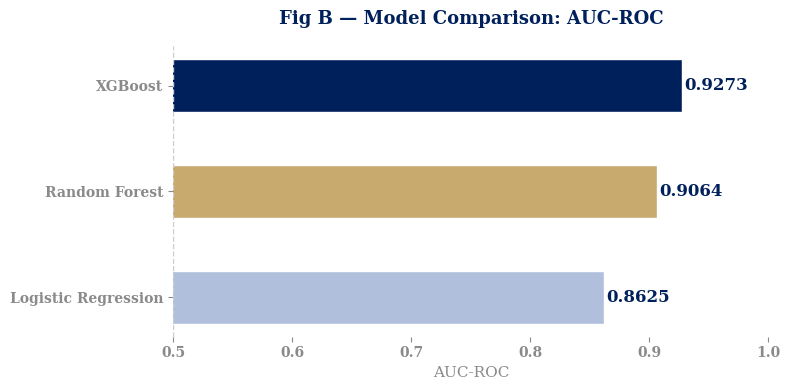

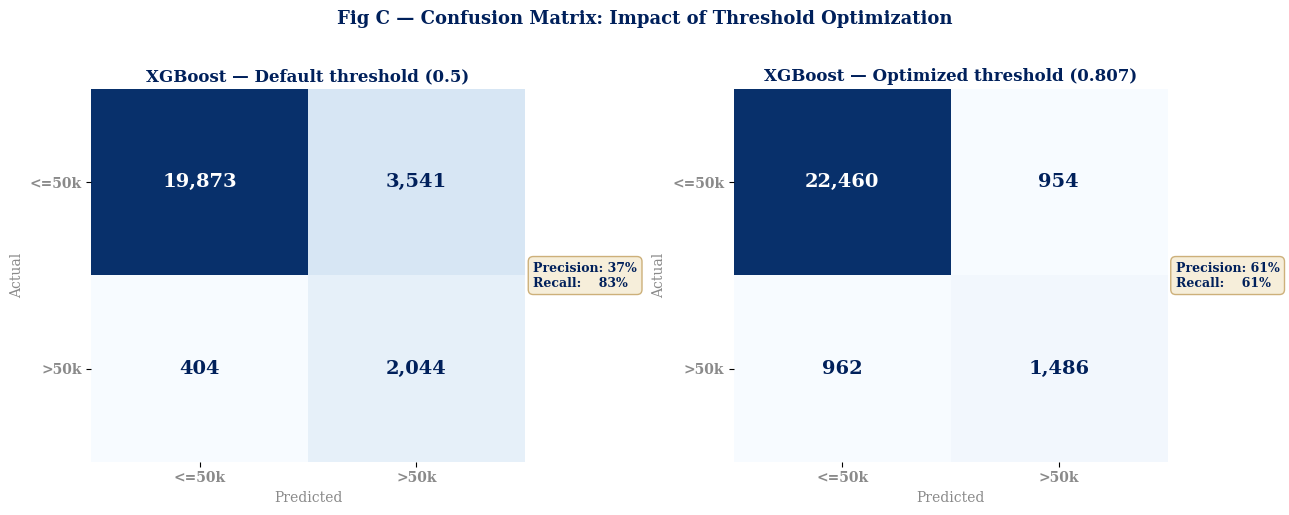

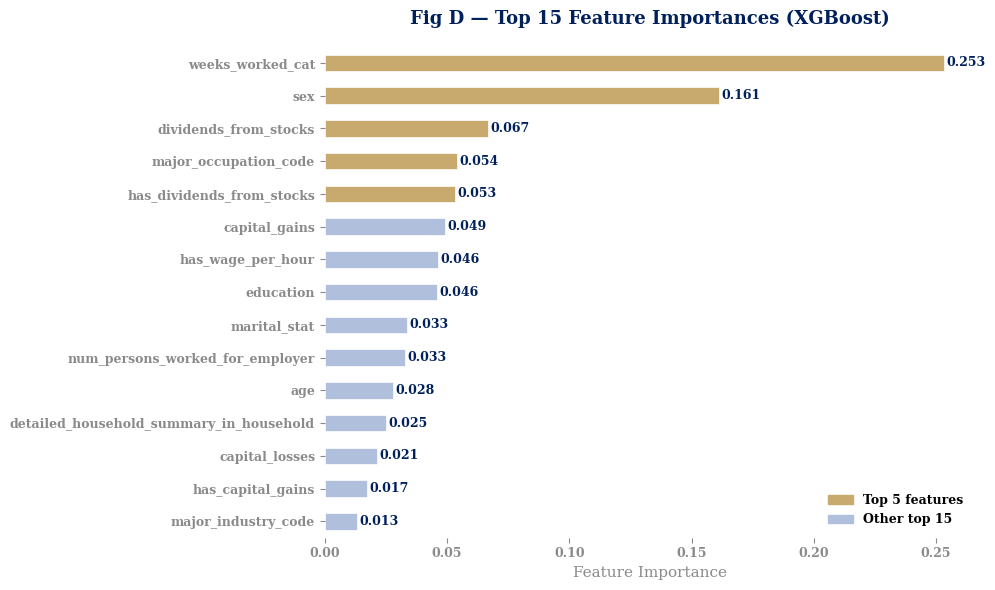

In [ ]:
# ── 6. ROC Curves ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors = [LNAVY, GOLD, NAVY]
for (name, res), color in zip(results.items(), colors):
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f"{name}  (AUC = {res['auc']:.3f})")

ax.plot([0,1],[0,1], color='#CCCCCC', linestyle='--', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=11, color=MGRAY)
ax.set_ylabel('True Positive Rate', fontsize=11, color=MGRAY)
ax.set_title('Fig  — ROC Curves: All Models', fontsize=13,
             fontweight='bold', color=NAVY, pad=16)
ax.legend(fontsize=10, frameon=False, loc='lower right')
ax.tick_params(colors=MGRAY)
plt.tight_layout()
plt.savefig('figA_roc_curves.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()


# ── 7. AUC Comparison Bar ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

names      = list(results.keys())
aucs       = [res['auc'] for res in results.values()]
bar_colors = [LNAVY, GOLD, NAVY]

bars = ax.barh(names, aucs, color=bar_colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, aucs):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=12,
            fontweight='bold', color=NAVY)

ax.axvline(0.5, color='#CCCCCC', linestyle='--', linewidth=1)
ax.set_xlim(0.5, max(aucs) * 1.08)
ax.set_xlabel('AUC-ROC', fontsize=11, color=MGRAY)
ax.set_title('Fig  — Model Comparison: AUC-ROC', fontsize=13,
             fontweight='bold', color=NAVY, pad=16)
ax.tick_params(colors=MGRAY)
plt.tight_layout()
plt.savefig('figB_auc_comparison.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()


# ── 8. Confusion Matrix: Default vs Optimized ────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (pred, title) in zip(axes, [
    (xgb_pred,   'Default threshold (0.5)'),
    (y_pred_opt, f'Optimized threshold ({best_thr:.3f})')
]):
    from sklearn.metrics import confusion_matrix
    cm    = confusion_matrix(y_test, pred)
    im    = ax.imshow(cm, cmap='Blues', aspect='auto')

    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i,j] > cm.max()/2 else NAVY
            ax.text(j, i, f'{cm[i,j]:,}',
                    ha='center', va='center',
                    fontsize=14, fontweight='bold', color=color)

    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['<=50k', '>50k'], color=MGRAY)
    ax.set_yticklabels(['<=50k', '>50k'], color=MGRAY)
    ax.set_xlabel('Predicted', color=MGRAY)
    ax.set_ylabel('Actual', color=MGRAY)
    ax.set_title(f'XGBoost — {title}', fontweight='bold', color=NAVY)

    tn, fp, fn, tp = cm.ravel()
    prec_val = tp / (tp + fp) if (tp+fp) > 0 else 0
    rec_val  = tp / (tp + fn) if (tp+fn) > 0 else 0
    ax.text(1.02, 0.5,
            f'Precision: {prec_val:.0%}\nRecall:    {rec_val:.0%}',
            transform=ax.transAxes, fontsize=9, color=NAVY, va='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#F5EDD6',
                      edgecolor=GOLD, alpha=0.9))

fig.suptitle('Fig  — Confusion Matrix: Impact of Threshold Optimization',
             fontsize=13, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig('figC_confusion_matrix.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()


# ── 9. Feature Importance ─────────────────────────────────────
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 6))

feat_imp = pd.Series(
    results['XGBoost']['model'].feature_importances_,
    index=X.columns
).nlargest(15).sort_values()

bar_colors = [GOLD if i >= len(feat_imp)-5 else LNAVY
              for i in range(len(feat_imp))]

feat_imp.plot(kind='barh', ax=ax, color=bar_colors,
              edgecolor='white', linewidth=0.5)

for i, (idx, val) in enumerate(feat_imp.items()):
    ax.text(val + 0.001, i, f'{val:.3f}', va='center',
            fontsize=9, color=NAVY, fontweight='bold')

ax.set_xlabel('Feature Importance', fontsize=11, color=MGRAY)
ax.set_title('Fig D — Top 15 Feature Importances (XGBoost)',
             fontsize=13, fontweight='bold', color=NAVY, pad=16)
ax.tick_params(colors=MGRAY, labelsize=9)

legend_patches = [
    mpatches.Patch(color=GOLD,  label='Top 5 features'),
    mpatches.Patch(color=LNAVY, label='Other top 15'),
]
ax.legend(handles=legend_patches, fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig('figD_feature_importance.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

### Download Evaluation Figures

In [ ]:
from google.colab import files
files.download('figA_roc_curves.png')
files.download('figB_auc_comparison.png')
files.download('figC_confusion_matrix.png')
files.download('figD_feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## Part IV: Customer Segmentation

**Goal:** Group working-age adults into distinct marketing personas based on life stage, employment intensity, and career profile.

**Why a separate segmentation model?**
The income classifier tells you *whether* to invest in a prospect.
The segmentation model tells you *who they are* and *how to approach them*.

**Population:** Working-age adults 18–65 in the labor force (93,124 records)
Note: this is a subset of the classifier population (18+). Retirees and those outside the labor market are excluded — their consumption patterns differ fundamentally from the retail marketing target.

**Feature selection rationale:** Aligned with classifier feature importance, excluding protected attributes:
| Feature | Classifier rank | Why included |
|---------|----------------|-------------|
| `weeks_worked_in_year` | #1 (0.253) | Employment intensity |
| `major_occupation_code` | #4 (0.054) | Career profile |
| `education` (4 tiers) | #5 (0.046) | Life stage proxy |
| `marital_stat` | #8 (0.033) | Household structure |
| `age` | #9 (0.028) | Life stage |
| `sex`, `race` | #2, excluded | **Bias risk — excluded** |

### 4.1 K Selection

Evaluate cluster quality for K=2 to K=7 using:
- **Silhouette score:** measures how well-separated clusters are (higher = better)
- **Elbow method:** inertia drop rate

Initial features include `dividends_from_stocks` to test whether asset ownership improves segmentation.

working-age labor force: 93,124
feature matrix: (93124, 28)
  K=2  silhouette=0.2887
  K=3  silhouette=0.3113
  K=4  silhouette=0.3144
  K=5  silhouette=0.2235
  K=6  silhouette=0.2239
  K=7  silhouette=0.1754


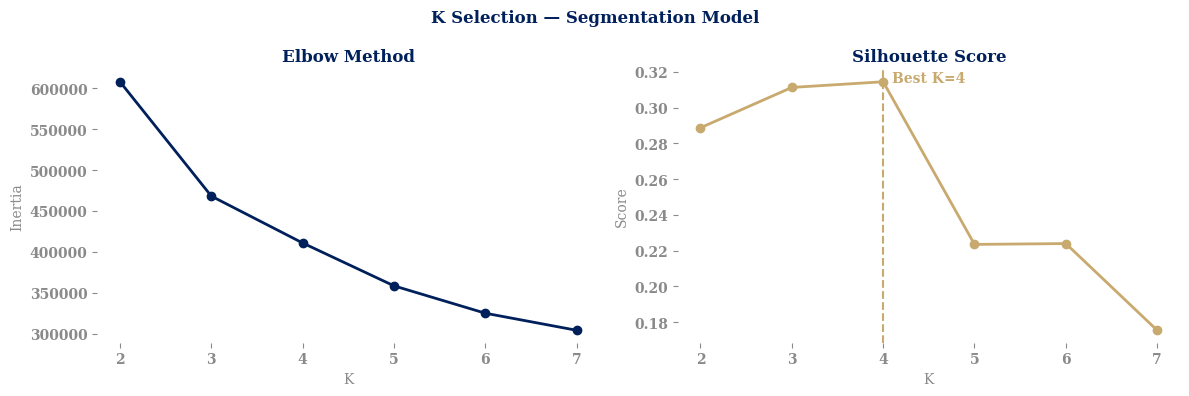


Best K by silhouette: 4  (score=0.3144)


In [ ]:
# ════════════════════════════════════════════════════════════
# STEP 1: K Selection — find optimal number of clusters
# Using original features including dividends_from_stocks
# ════════════════════════════════════════════════════════════

NAVY = "#00205B"
GOLD = "#C8A96E"
LNAVY = "#B0BFDB"
MGRAY = "#8A8A8A"

# ── 1. rebuild from original df ───────────────────────────────
seg = df.copy()
seg['high_income'] = (df['label'].str.strip() == '50000+.').astype(int)
seg['age'] = pd.to_numeric(seg['age'], errors='coerce')

# ── 2. filter to working-age labor force ──────────────────────
seg = seg[
    (seg['age'].between(18, 65)) &
    (seg['major_industry_code'] != 'Not in universe or children') &
    (seg['full_or_part_time_employment_stat'] != 'Not in labor force')
].copy()
print(f"working-age labor force: {len(seg):,}")

# ── 3. education grouping ─────────────────────────────────────
edu_map = {
    'Less than 1st grade':                    'Low',
    '1st 2nd 3rd or 4th grade':               'Low',
    '5th or 6th grade':                       'Low',
    '7th and 8th grade':                      'Low',
    '9th grade':                              'Low',
    '10th grade':                             'Low',
    '11th grade':                             'Low',
    '12th grade no diploma':                  'Low',
    'High school graduate':                   'High school',
    'Some college but no degree':             'Some college',
    'Associates degree-occup /vocational':    'Some college',
    'Associates degree-academic program':     'Some college',
    'Bachelors degree(BA AB BS)':             'Bachelor+',
    'Masters degree(MA MS MEng MEd MSW MBA)': 'Bachelor+',
    'Prof school degree (MD DDS DVM LLB JD)': 'Bachelor+',
    'Doctorate degree(PhD EdD)':              'Bachelor+',
}
seg['edu_grp'] = seg['education'].map(edu_map).fillna('Other')

# ── 4. select features — aligned with feature importance ──────
# weeks_worked (#1), education (#7), marital_stat (#8), age (#9)
# occupation (#4 — better than industry), dividends (#3 + #5)
# Excluded: sex (#2, bias risk), race (bias risk)
NUM_COLS = ['age', 'weeks_worked_in_year', 'dividends_from_stocks']
ORD_COLS = ['edu_grp']
CAT_COLS = ['marital_stat', 'major_occupation_code']

seg_sel = seg[NUM_COLS + ORD_COLS + CAT_COLS + ['high_income']].copy()
seg_sel[NUM_COLS] = seg_sel[NUM_COLS].apply(pd.to_numeric, errors='coerce')

# impute
imputer = SimpleImputer(strategy='most_frequent')
seg_sel[NUM_COLS + ORD_COLS + CAT_COLS] = imputer.fit_transform(
    seg_sel[NUM_COLS + ORD_COLS + CAT_COLS]
)
seg_sel[NUM_COLS] = seg_sel[NUM_COLS].astype(float)

# ── 5. preprocessing ──────────────────────────────────────────
preproc = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('ord', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ORD_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
])
X_proc = preproc.fit_transform(seg_sel[NUM_COLS + ORD_COLS + CAT_COLS])

# upweight age and weeks_worked — most important segmentation dimensions
X_proc[:, 0] *= 2.0   # age
X_proc[:, 1] *= 1.5   # weeks_worked
print(f"feature matrix: {X_proc.shape}")

# ── 6. find optimal K ─────────────────────────────────────────
inertia_vals, sil_vals = [], []
K_RANGE = range(2, 8)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_proc)
    inertia_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_proc, labels))
    print(f"  K={k}  silhouette={sil_vals[-1]:.4f}")

# ── 7. plot K selection ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_RANGE, inertia_vals, color=NAVY, marker='o', linewidth=2)
axes[0].set_title('Elbow Method', fontweight='bold', color=NAVY)
axes[0].set_xlabel('K', color=MGRAY)
axes[0].set_ylabel('Inertia', color=MGRAY)
axes[0].tick_params(colors=MGRAY)

axes[1].plot(K_RANGE, sil_vals, color=GOLD, marker='o', linewidth=2)
axes[1].set_title('Silhouette Score', fontweight='bold', color=NAVY)
axes[1].set_xlabel('K', color=MGRAY)
axes[1].set_ylabel('Score', color=MGRAY)
axes[1].tick_params(colors=MGRAY)

best_k = K_RANGE[sil_vals.index(max(sil_vals))]
axes[1].axvline(best_k, color=GOLD, linestyle='--', linewidth=1.5)
axes[1].text(best_k+0.1, max(sil_vals), f'Best K={best_k}',
             color=GOLD, fontweight='bold', fontsize=10)

plt.suptitle('K Selection — Segmentation Model', fontweight='bold', color=NAVY)
plt.tight_layout()
plt.savefig('fig_k_selection.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nBest K by silhouette: {best_k}  (score={max(sil_vals):.4f})")

### 4.2 Try K=4 (Highest Silhouette)

K=4 achieved the highest silhouette score (0.3144). Profile each cluster to check whether all four are actionable.

In [ ]:
# ════════════════════════════════════════════════════════════
# STEP 2: Try K=4 first (highest silhouette)
# ════════════════════════════════════════════════════════════

km4 = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=42)
seg_sel['cluster'] = km4.fit_predict(X_proc)

profile4 = seg_sel.groupby('cluster').agg(
    count            = ('high_income', 'count'),
    high_income_rate = ('high_income', 'mean'),
    avg_age          = ('age', 'mean'),
    avg_weeks        = ('weeks_worked_in_year', 'mean'),
).round(3)
profile4['pct_of_total']     = (profile4['count'] / profile4['count'].sum() * 100).round(1)
profile4['high_income_rate'] = (profile4['high_income_rate'] * 100).round(1)
print("── K=4 Profile ──")
print(profile4.sort_values('high_income_rate', ascending=False))

for c in range(4):
    sub = seg_sel[seg_sel['cluster'] == c]
    top_occ = seg.loc[sub.index, 'major_occupation_code'].value_counts().head(1)
    print(f"\nCluster {c}: {len(sub):,} people | high income: {sub['high_income'].mean()*100:.1f}% | top occ: {top_occ.index[0]}")


── K=4 Profile ──
         count  high_income_rate  avg_age  avg_weeks  pct_of_total
cluster                                                           
0        20888              18.9   54.463     48.971          22.4
1        34121              16.6   40.007     50.635          36.6
3        27317               5.0   26.604     49.775          29.3
2        10798               1.1   31.139     12.960          11.6

Cluster 0: 20,888 people | high income: 18.9% | top occ: Executive admin and managerial

Cluster 1: 34,121 people | high income: 16.6% | top occ: Professional specialty

Cluster 2: 10,798 people | high income: 1.1% | top occ: Other service

Cluster 3: 27,317 people | high income: 5.0% | top occ: Adm support including clerical


### 4.3 Business Judgment: Reject K=4, Switch to K=3

**Problem identified:** K=4 produced a cluster of only 144 people (0.15% of population).

**Root cause:** `dividends_from_stocks` is 96% zero. The handful of high-dividend earners form a statistically distinct but **completely unactionable** micro-cluster.

**Decision:**
- Remove `dividends_from_stocks` from segmentation features
- Refit with K=3 (silhouette = 0.3113, difference from K=4 = 0.003 — negligible)
- K=3 produces three balanced clusters (41% / 47% / 12%) with clear, distinct personas

> The silhouette difference between K=4 and K=3 is 0.003. The business value difference is not.

In [ ]:
# ════════════════════════════════════════════════════════════
# STEP 3: Business judgment — K=4 rejected, switch to K=3
#
# Problem: Cluster 3 contains only 144 people (0.15% of total).
# This is an artifact of dividends_from_stocks being 96% zero —
# the handful of high-dividend earners form a micro-cluster.
# A segment of 144 has no actionable marketing value.
#
# Decision: remove dividends_from_stocks from segmentation features
# and refit with K=3 (silhouette=0.3113, marginal difference of 0.003).
# K=3 produces three balanced, interpretable personas.
# ════════════════════════════════════════════════════════════

NUM_COLS = ['age', 'weeks_worked_in_year']   # dividends removed
ORD_COLS = ['edu_grp']
CAT_COLS = ['marital_stat', 'major_occupation_code']

seg_sel = seg[NUM_COLS + ORD_COLS + CAT_COLS + ['high_income']].copy()
seg_sel[NUM_COLS] = seg_sel[NUM_COLS].apply(pd.to_numeric, errors='coerce')

imputer = SimpleImputer(strategy='most_frequent')
seg_sel[NUM_COLS + ORD_COLS + CAT_COLS] = imputer.fit_transform(
    seg_sel[NUM_COLS + ORD_COLS + CAT_COLS])
seg_sel[NUM_COLS] = seg_sel[NUM_COLS].astype(float)

preproc = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('ord', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ORD_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
])
X_proc_v2 = preproc.fit_transform(seg_sel[NUM_COLS + ORD_COLS + CAT_COLS])
X_proc_v2[:, 0] *= 2.0
X_proc_v2[:, 1] *= 1.5

km3 = KMeans(n_clusters=3, init='k-means++', n_init=20, random_state=42)
seg_sel['cluster'] = km3.fit_predict(X_proc_v2)

print("\n── K=3 Final Profile ──")
profile3 = seg_sel.groupby('cluster').agg(
    count            = ('high_income', 'count'),
    high_income_rate = ('high_income', 'mean'),
    avg_age          = ('age', 'mean'),
    avg_weeks        = ('weeks_worked_in_year', 'mean'),
).round(3)
profile3['pct_of_total']     = (profile3['count'] / profile3['count'].sum() * 100).round(1)
profile3['high_income_rate'] = (profile3['high_income_rate'] * 100).round(1)
print(profile3.sort_values('high_income_rate', ascending=False))

for c in range(3):
    sub = seg_sel[seg_sel['cluster'] == c]
    top_occ = seg.loc[sub.index, 'major_occupation_code'].value_counts(normalize=True).head(3)
    top_mar = sub['marital_stat'].value_counts(normalize=True).head(3)
    top_edu = sub['edu_grp'].value_counts(normalize=True).head(3)
    print(f"\n── Cluster {c}  ({len(sub):,} people,  {len(sub)/len(seg_sel)*100:.1f}%)  ──")
    print(f"  high income: {sub['high_income'].mean()*100:.1f}%  |  avg age: {sub['age'].mean():.1f}  |  avg weeks: {sub['weeks_worked_in_year'].mean():.1f}")
    for occ, pct in top_occ.items(): print(f"  occ: {occ:<45} {pct:.1%}")
    for mar, pct in top_mar.items(): print(f"  mar: {mar:<45} {pct:.1%}")
    for edu, pct in top_edu.items(): print(f"  edu: {edu:<45} {pct:.1%}")


── K=3 Final Profile ──
         count  high_income_rate  avg_age  avg_weeks  pct_of_total
cluster                                                           
1        38410              18.8   49.394     49.860          41.2
0        43259               8.6   30.313     50.356          46.5
2        11455               1.2   31.182     13.687          12.3

── Cluster 0  (43,259 people,  46.5%)  ──
  high income: 8.6%  |  avg age: 30.3  |  avg weeks: 50.4
  occ: Adm support including clerical                15.8%
  occ: Professional specialty                        13.7%
  occ: Executive admin and managerial                12.0%
  mar: Married-civilian spouse present               53.3%
  mar: Never married                                 34.9%
  mar: Divorced                                      7.6%
  edu: High school                                   33.7%
  edu: Some college                                  31.9%
  edu: Bachelor+                                     24.5%

── Clust

### 4.4 PCA Visualization

Project the high-dimensional cluster space onto 2 principal components for visualization.
Stars (★) mark cluster centroids.

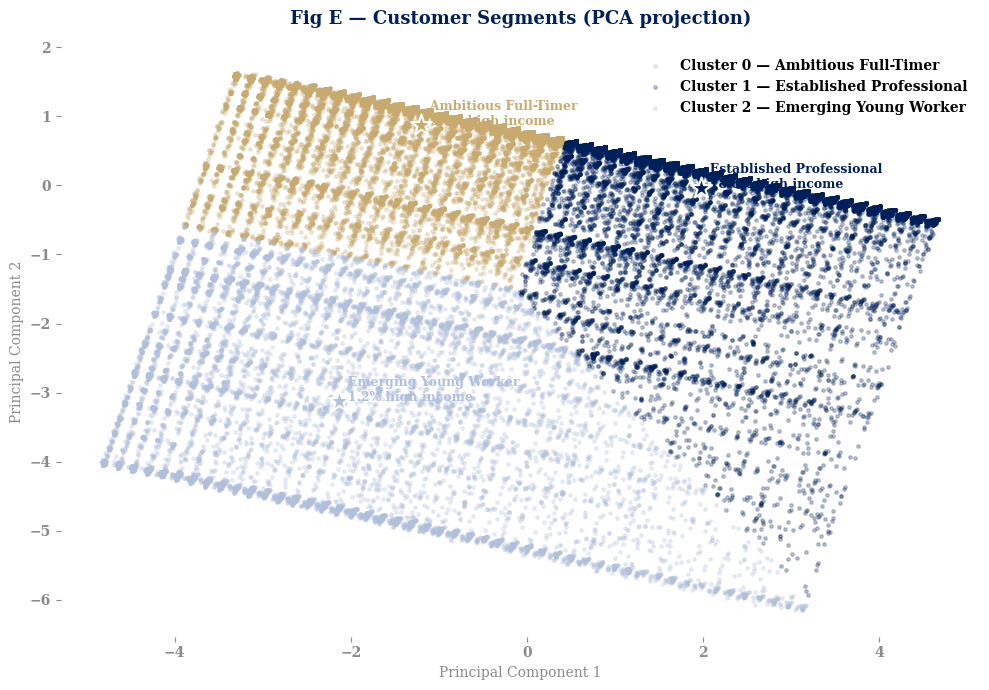

In [ ]:
# ════════════════════════════════════════════════════════════
# STEP 4: PCA visualization
# ════════════════════════════════════════════════════════════

from sklearn.decomposition import PCA

cluster_names = {0:'Ambitious Full-Timer', 1:'Established Professional', 2:'Emerging Young Worker'}
colors_map    = {0:GOLD, 1:NAVY, 2:LNAVY}

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_proc_v2)

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(3):
    mask = seg_sel['cluster'] == c
    ax.scatter(X_pca[mask,0], X_pca[mask,1],
               c=colors_map[c], alpha=0.25, s=6,
               label=f"Cluster {c} — {cluster_names[c]}")

centers_pca = pca.transform(km3.cluster_centers_)
for c in range(3):
    ax.scatter(centers_pca[c,0], centers_pca[c,1],
               c=colors_map[c], s=250, marker='*',
               edgecolors='white', linewidth=1.5, zorder=5)
    hi = profile3.loc[c, 'high_income_rate']
    ax.annotate(f"  {cluster_names[c]}\n  {hi}% high income",
                (centers_pca[c,0], centers_pca[c,1]),
                fontsize=9, fontweight='bold', color=colors_map[c])

ax.set_title('Fig E — Customer Segments (PCA projection)',
             fontsize=13, fontweight='bold', color=NAVY, pad=16)
ax.set_xlabel('Principal Component 1', color=MGRAY)
ax.set_ylabel('Principal Component 2', color=MGRAY)
ax.legend(fontsize=10, frameon=False)
ax.tick_params(colors=MGRAY)
plt.tight_layout()
plt.savefig('figE_segments_pca.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

### 4.5 Cluster Profile Analysis

Visualize the three personas across six dimensions:
- Age distribution
- Weeks worked distribution
- High-income rate comparison
- Education breakdown
- Marital status breakdown
- Top occupations per cluster

/tmp/ipykernel_325/2874780313.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([cluster_names[c] for c in range(3)], rotation=15, ha='right', fontsize=8)


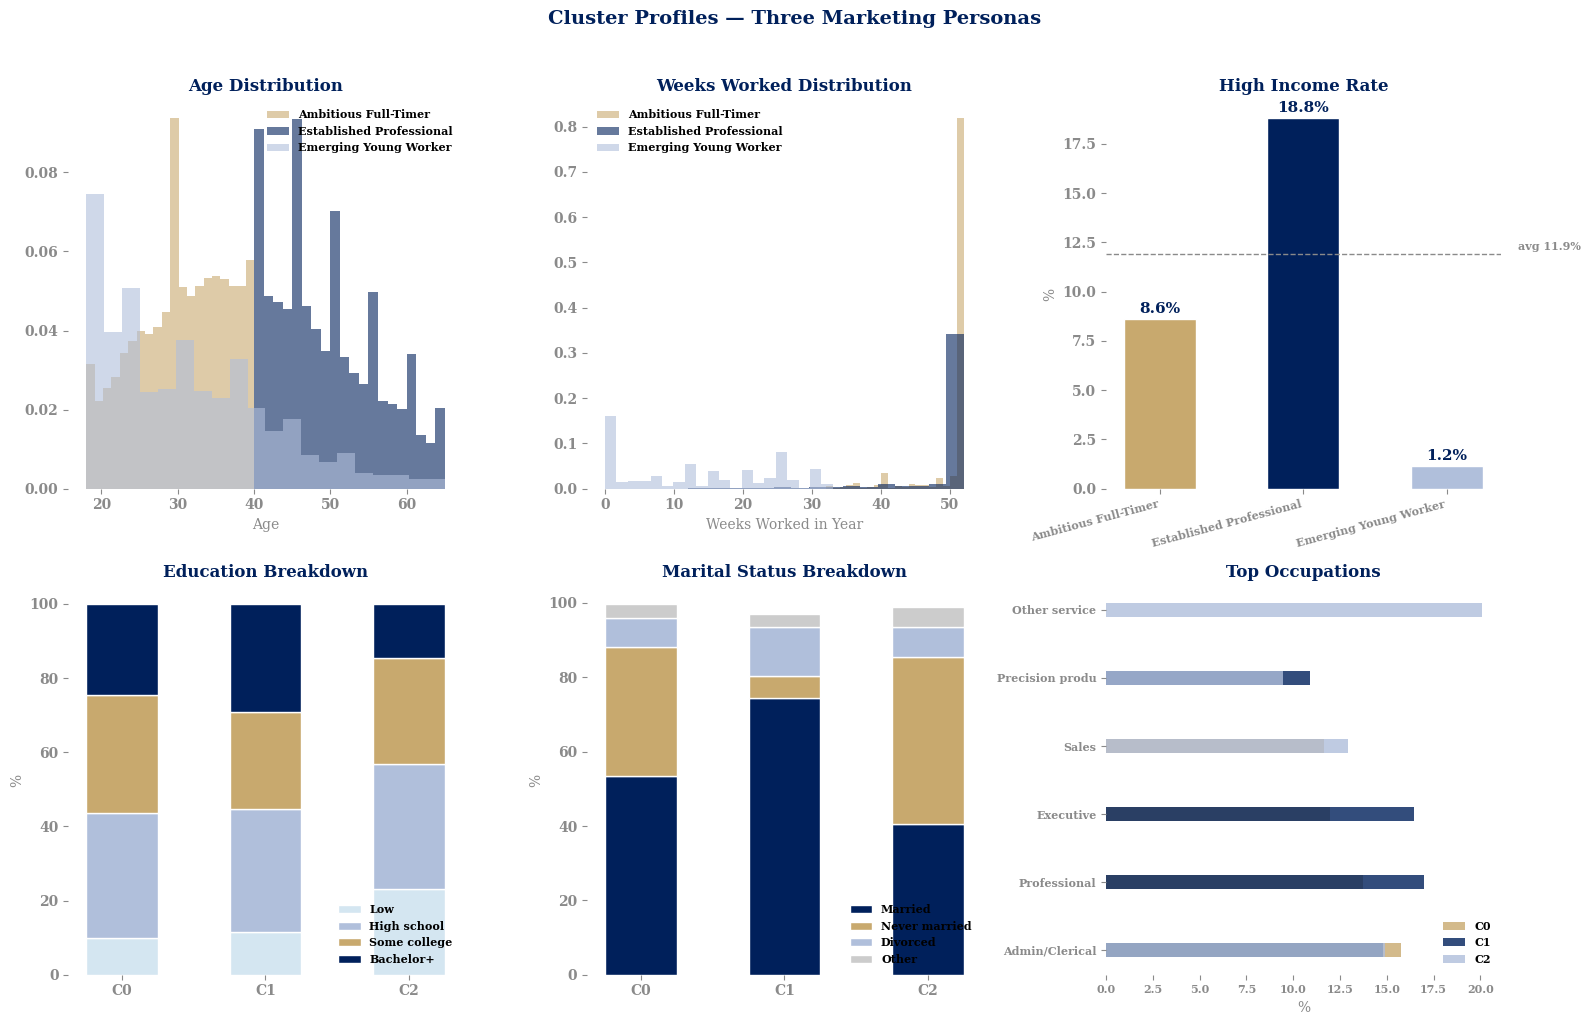

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Cluster Profiles — Three Marketing Personas',
             fontsize=14, fontweight='bold', color=NAVY, y=1.02)

cluster_names = {0:'Ambitious Full-Timer', 1:'Established Professional', 2:'Emerging Young Worker'}
colors_map    = {0:GOLD, 1:NAVY, 2:LNAVY}

# ── Fig 1: Age distribution per cluster ──────────────────────
ax = axes[0, 0]
for c in range(3):
    sub = seg_sel[seg_sel['cluster'] == c]['age']
    ax.hist(sub, bins=20, alpha=0.6, color=colors_map[c],
            label=cluster_names[c], density=True)
ax.set_title('Age Distribution', fontweight='bold', color=NAVY)
ax.set_xlabel('Age', color=MGRAY)
ax.legend(fontsize=8, frameon=False)
ax.tick_params(colors=MGRAY)

# ── Fig 2: Weeks worked distribution ─────────────────────────
ax = axes[0, 1]
for c in range(3):
    sub = seg_sel[seg_sel['cluster'] == c]['weeks_worked_in_year']
    ax.hist(sub, bins=20, alpha=0.6, color=colors_map[c],
            label=cluster_names[c], density=True)
ax.set_title('Weeks Worked Distribution', fontweight='bold', color=NAVY)
ax.set_xlabel('Weeks Worked in Year', color=MGRAY)
ax.legend(fontsize=8, frameon=False)
ax.tick_params(colors=MGRAY)

# ── Fig 3: High income rate per cluster ──────────────────────
ax = axes[0, 2]
rates = [seg_sel[seg_sel['cluster']==c]['high_income'].mean()*100 for c in range(3)]
bars  = ax.bar([cluster_names[c] for c in range(3)], rates,
               color=[colors_map[c] for c in range(3)],
               edgecolor='white', width=0.5)
for bar, val in zip(bars, rates):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.3,
            f'{val:.1f}%', ha='center', fontweight='bold', color=NAVY, fontsize=11)
ax.axhline(seg_sel['high_income'].mean()*100, color=MGRAY,
           linestyle='--', linewidth=1)
ax.text(2.5, seg_sel['high_income'].mean()*100+0.2,
        f'avg {seg_sel["high_income"].mean()*100:.1f}%',
        fontsize=8, color=MGRAY)
ax.set_title('High Income Rate', fontweight='bold', color=NAVY)
ax.set_ylabel('%', color=MGRAY)
ax.tick_params(colors=MGRAY)
ax.set_xticklabels([cluster_names[c] for c in range(3)], rotation=15, ha='right', fontsize=8)

# ── Fig 4: Education breakdown per cluster ───────────────────
ax = axes[1, 0]
edu_order = ['Low', 'High school', 'Some college', 'Bachelor+']
edu_colors = ['#D4E6F1', LNAVY, GOLD, NAVY]
bottom = np.zeros(3)
for edu, color in zip(edu_order, edu_colors):
    vals = [seg_sel[seg_sel['cluster']==c]['edu_grp'].value_counts(normalize=True).get(edu, 0)*100
            for c in range(3)]
    ax.bar(range(3), vals, bottom=bottom, color=color,
           label=edu, edgecolor='white', width=0.5)
    bottom += np.array(vals)
ax.set_title('Education Breakdown', fontweight='bold', color=NAVY)
ax.set_xticks(range(3))
ax.set_xticklabels([f'C{c}' for c in range(3)])
ax.set_ylabel('%', color=MGRAY)
ax.legend(fontsize=8, frameon=False, loc='lower right')
ax.tick_params(colors=MGRAY)

# ── Fig 5: Marital status per cluster ────────────────────────
ax = axes[1, 1]
mar_map = {
    'Married-civilian spouse present': 'Married',
    'Never married': 'Never married',
    'Divorced': 'Divorced',
    'Widowed': 'Widowed',
    'Married-spouse absent': 'Other',
    'Separated': 'Other',
}
seg_sel['mar_simple'] = seg_sel['marital_stat'].map(mar_map).fillna('Other')
mar_order  = ['Married', 'Never married', 'Divorced', 'Other']
mar_colors = [NAVY, GOLD, LNAVY, '#CCCCCC']
bottom = np.zeros(3)
for mar, color in zip(mar_order, mar_colors):
    vals = [seg_sel[seg_sel['cluster']==c]['mar_simple'].value_counts(normalize=True).get(mar, 0)*100
            for c in range(3)]
    ax.bar(range(3), vals, bottom=bottom, color=color,
           label=mar, edgecolor='white', width=0.5)
    bottom += np.array(vals)
ax.set_title('Marital Status Breakdown', fontweight='bold', color=NAVY)
ax.set_xticks(range(3))
ax.set_xticklabels([f'C{c}' for c in range(3)])
ax.set_ylabel('%', color=MGRAY)
ax.legend(fontsize=8, frameon=False, loc='lower right')
ax.tick_params(colors=MGRAY)

# ── Fig 6: Top occupations per cluster ───────────────────────
ax = axes[1, 2]
occ_short = {
    'Professional specialty':           'Professional',
    'Executive admin and managerial':   'Executive',
    'Adm support including clerical':   'Admin/Clerical',
    'Sales':                            'Sales',
    'Other service':                    'Other service',
    'Craft and repair':                 'Craft & repair',
    'Machine operators assmblrs & inspctrs': 'Machine ops',
    'Transportation and material moving': 'Transport',
    'Handlers equip cleaners etc':      'Handlers',
    'Farming forestry and fishing':     'Farming',
}
top_occs = seg.loc[seg_sel.index, 'major_occupation_code'].map(
    lambda x: occ_short.get(x, x[:15]))
seg_sel['occ_short'] = top_occs.values

for i, c in enumerate(range(3)):
    sub_occ = seg_sel[seg_sel['cluster']==c]['occ_short'].value_counts(normalize=True).head(4)
    y_pos = np.arange(len(sub_occ)) + i*0.25
    ax.barh(sub_occ.index, sub_occ.values*100,
            color=colors_map[c], alpha=0.8, height=0.2,
            label=f'C{c}')

ax.set_title('Top Occupations', fontweight='bold', color=NAVY)
ax.set_xlabel('%', color=MGRAY)
ax.legend(fontsize=8, frameon=False)
ax.tick_params(colors=MGRAY, labelsize=8)

plt.tight_layout()
plt.savefig('figF_cluster_profiles.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

---

## Summary

| Model | Key result |
|-------|------------|
| XGBoost Classifier | AUC = 0.927, 6.4x lift at threshold 0.807 |
| K-Means Segmentation | K=3, silhouette = 0.3113 |

**Three marketing personas identified:**
- 🏆 **Established Professional** (41%): avg age 49, full-year, 18.8% high-income → premium campaigns
- 📈 **Ambitious Full-Timer** (47%): avg age 30, full-year, 8.6% high-income → mid-tier aspirational
- 🌱 **Emerging Young Worker** (12%): avg age 31, part-time, 1.2% high-income → low-cost acquisition

Use the income score to decide **whether** to invest. Use the persona to decide **how** to approach.